# Machine Learning Project: Identifying Underinsured Individuals for Targeted Insurance Outreach

**Course:** Applied Machine Learning (CINTO2401U.LA_E25)

**Group:** 9 (Georg Sulzer, Justus Leopold Krauss, Max Häfke, Vincent Paul Konrad Wallerich)

---

## 0. Project Overview

This project explores how machine learning can help a private insurer identify potentially underinsured individuals, specifically those covered exclusively by Medicaid, to support more effective targeted outreach strategies. Using U.S. Census PUMS data, we examine how different levels of information availability influence model performance and practical deployment potential.

### 0.1 Business Case

Our goal is to identify individuals in the US who may be underinsured and therefore likely to benefit from supplementary private insurance products. In this project, we define “underinsured” as individuals who rely **exclusively on Medicaid**, since Medicaid provides only limited coverage and may leave gaps that private insurance can fill.

From the perspective of a private insurer, the ability to predict which individuals fall into this group is highly valuable:  
1. **Targeted marketing becomes more efficient**, as outreach can be focused on people with a higher need for additional coverage.  
2. **Customer acquisition costs can be reduced**, which is especially important given constraints such as limited marketing budgets and no access to public insurance databases.

By predicting whether a person has only Medicaid coverage using statistical, publicly accessible, or insurer-available features, the company can more precisely target potential customers and substantially improve the effectiveness and efficiency of its online advertising strategy.

### 0.2 Machine Learning Problem

The task in this project is formulated as a **binary classification problem** in which we aim to predict whether an individual is insured **only through Medicaid** or has any other or additional form of health insurance. To address this, we apply several classification models and evaluate their performance under different feature availability scenarios, ranging from minimal publicly accessible information to richer business-specific attributes. The objective is to determine how accurately we can identify potentially underinsured individuals using various levels of data granularity and model complexity.

### 0.3 Data Set

For this project, we use the **2023 Public Use Microdata Sample (PUMS)** from the **U.S. Census Bureau’s American Community Survey (ACS)**. The PUMS dataset provides individual-level, anonymized microdata with detailed demographic, socioeconomic, employment, and health insurance information for millions of U.S. residents. 

Because the full national dataset contains roughly three million person-level records - making computation more demanding - we focus our analysis on the **New England states**. However, the methods and models developed here are fully applicable to any other PUMS region or the nationwide dataset.

### 0.4 Pipeline Overview

The Jupyter Notebook is structured as a sequential pipeline that can be executed from start to finish. All required input data is provided in the `data` directory, allowing the notebook to be run end-to-end without manual intervention. The pipeline consists of the following steps: (1) data loading and optional exploratory analyses for data understanding, (2) data cleaning and feature engineering, (3) model training, (4) model evaluation, and (5) fairness analysis.

*Note:* Running the complete notebook typically takes around 30 minutes on our machines, as model training and hyperparameter tuning are computationally intensive.

---

## 1. Data

Before preparing the data for model training, we explore the raw dataset to gain an understanding of its structure and features.

> *Section 1.1 covers the setup and data loading process. Sections 1.2–1.4 provide additional analyses for data understanding and intuition, including data quality checks, health insurance coverage combinations, and exploratory feature analysis. These sections are exploratory in nature and optional to run, and they do not affect the subsequent modelling pipeline.*

### 1.1 Setup and Data Loading

We import all required libraries, configure global settings, and define path dependencies for loading and processing the dataset.


In [3]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
import logging
from datetime import datetime
from pathlib import Path
from sklearn.feature_selection import VarianceThreshold
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix, average_precision_score
import joblib
from sklearn.metrics import RocCurveDisplay, ConfusionMatrixDisplay
import re
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.neural_network import MLPClassifier
from imblearn.over_sampling import SMOTE
from sklearn.dummy import DummyClassifier
import time

# Configuration
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
logging.basicConfig(level=logging.INFO, format='%(message)s')
logger = logging.getLogger()

# Define Paths
DATA_DIR = '00 data/raw/'
RAW_FILES = [
    'connecticut.csv', 'maine.csv', 'massachusetts.csv', 
    'new_hampshire.csv', 'rhode_island.csv', 'vermont.csv'
]

In [4]:
from fairlearn.metrics import (
    MetricFrame,
    true_positive_rate,
    false_positive_rate,
    selection_rate,
    equalized_odds_difference,
    demographic_parity_difference,
    demographic_parity_ratio,
)
from fairlearn.postprocessing import ThresholdOptimizer

We then load the raw **ACS PUMS 2023** data for the New England states and combine the individual state files into a single dataframe, which forms the basis for all subsequent analyses.

In [5]:
# Load and concatenate raw data files
dfs = [
    pd.read_csv(os.path.join(DATA_DIR, file))
    for file in set(RAW_FILES)
    if os.path.exists(os.path.join(DATA_DIR, file))
]

df_raw = pd.concat(dfs, ignore_index=True)

print(f"All data loaded. Total rows: {len(df_raw):,}")

All data loaded. Total rows: 158,895


In [6]:
print(f"Data Shape: {df_raw.shape[0]:,} rows, {df_raw.shape[1]} columns")
display(df_raw.head(5))

Data Shape: 158,895 rows, 286 columns


,RT,SERIALNO,DIVISION,SPORDER,PUMA,REGION,STATE,ADJINC,PWGTP,AGEP,...,PWGTP71,PWGTP72,PWGTP73,PWGTP74,PWGTP75,PWGTP76,PWGTP77,PWGTP78,PWGTP79,PWGTP80
0,P,2024GQ0000107,1,1,301,1,33,1015250,23,18,...,19,20,18,2,25,45,29,1,2,25
1,P,2024GQ0000543,1,1,301,1,33,1015250,115,68,...,118,118,114,114,120,114,112,122,116,110
2,P,2024GQ0000989,1,1,701,1,33,1015250,74,86,...,49,8,72,158,86,74,8,63,120,73
3,P,2024GQ0001295,1,1,701,1,33,1015250,17,75,...,13,4,17,25,17,16,4,18,26,18
4,P,2024GQ0002675,1,1,501,1,33,1015250,42,20,...,81,3,3,87,36,51,90,40,68,140


### 1.2 Data Quality Checks *(optional)*

We then assess data quality by (1) checking for duplicate records and (2) analyzing the presence of missing values across all features. This helps identify potential data issues and informs subsequent cleaning and imputation decisions.

In [7]:
# Check duplicates
dup_count = df_raw.duplicated(keep=False).sum()  # keep=False marks all duplicates as True
dup_pct = (dup_count / len(df_raw)) * 100
print(f"Duplicate Rows: {dup_count:,} ({dup_pct:.2f}% of dataset)")

Duplicate Rows: 0 (0.00% of dataset)


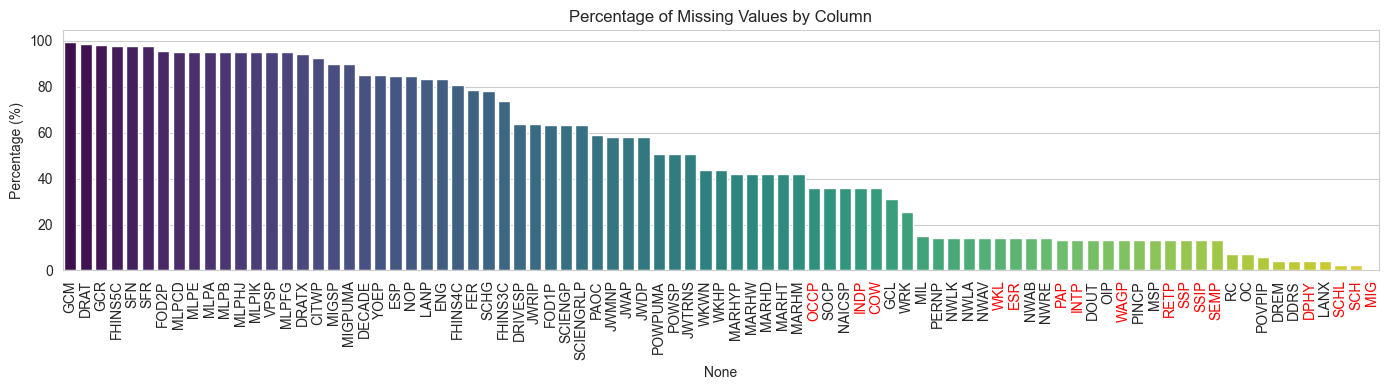

In [8]:
# Check missing values
missing = df_raw.isnull().sum()
missing = missing[missing > 0]

missing_pct = (missing / len(df_raw)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Percentage': missing_pct})

# Sort by percentage descending
missing_df = missing_df.sort_values('Percentage', ascending=False)

# Plot
plt.figure(figsize=(14, 4))
ax = sns.barplot(
    x=missing_df.index,
    y=missing_df['Percentage'],
    palette='viridis'
)

plt.title('Percentage of Missing Values by Column')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=90)

# Highlight selected features from 2.1 Feature Selection
keep_cols = ['WAGP', 'SEMP', 'INTP', 'RETP', 'SSP', 'SSIP', 'PAP', 'ESR', 'COW', 'WKL', 'OCCP', 'INDP', 'AGEP', 'SEX', 'MAR', 'MIG', 'NATIVITY', 'RAC1P', 'HISP','SCHL', 'SCH', 'DIS', 'DEAR', 'DEYE', 'DPHY', 'STATE', 'PUMA']

for label in ax.get_xticklabels():
    if label.get_text() in keep_cols:
        label.set_color('red')

plt.tight_layout()
plt.show()

*Note:* Features highlighted in **red** indicate variables retained for modelling during the feature selection step (Section 2.1). While the dataset contains a substantial number of missing values overall, the selected features have manageable levels of missingness, which are addressed in the data cleaning process (Section 2.2).

### 1.3 Health Insurance Combinations & Class Imbalances *(optional)*

The PUMS dataset contains seven binary health insurance indicators (`HINS1`–`HINS7`) representing different types of coverage, which can occur in *various combinations* for each individual. We analyze the most common combinations of these indicators (1) to understand how insurance coverage is structured in the data and (2) to gain an initial understanding of potential class imbalances relevant for the subsequent modelling task.

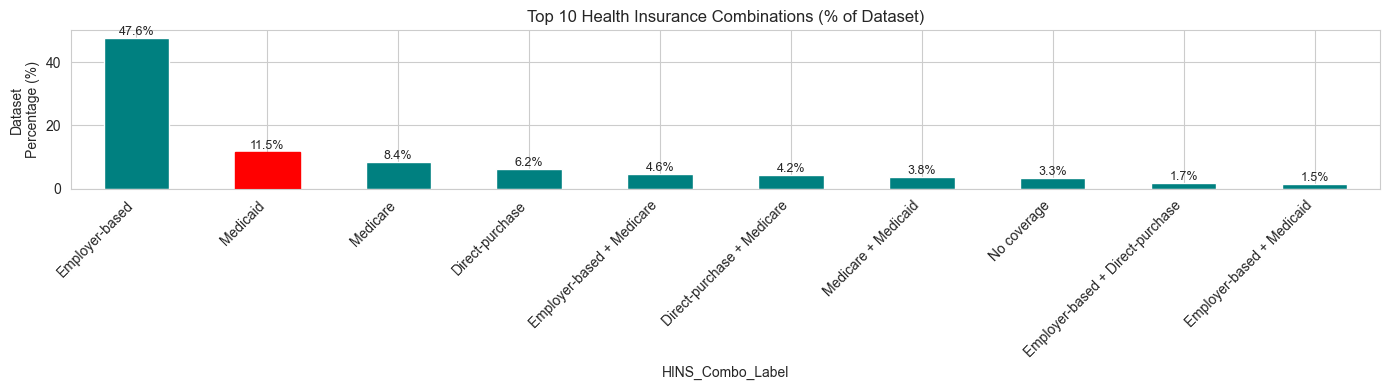

In [9]:
# Define HINS labels
hins_labels = {
    'HINS1': 'Employer-based',
    'HINS2': 'Direct-purchase',
    'HINS3': 'Medicare',
    'HINS4': 'Medicaid',
    'HINS5': 'Tricare/VA',
    'HINS6': 'Other public',
    'HINS7': 'No coverage'
}

# Identify health insurance indicator columns
hins_cols = sorted([c for c in df_raw.columns if c.startswith('HINS') and len(c) == 5])

# Create a readable combination label per individual
def map_hins_combo(row):
    combo_parts = []
    for col in hins_cols:
        if row[col] == 1:
            combo_parts.append(hins_labels.get(col, col))
    return ' + '.join(combo_parts) if combo_parts else 'No coverage'

df_raw['HINS_Combo_Label'] = df_raw.apply(map_hins_combo, axis=1)

# Get most frequent combinations
top_combos = (
    df_raw['HINS_Combo_Label']
    .value_counts(normalize=True)
    .head(10) * 100
)

# Plot top combinations
plt.figure(figsize=(14, 4))
ax = top_combos.plot(kind='bar', color='teal')

# Highlight Medicaid-only bar in red
for i, label in enumerate(top_combos.index):
    if label == 'Medicaid':
        ax.patches[i].set_color('red')

# Add percentage labels on bars
for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f'{height:.1f}%',
        (p.get_x() + p.get_width() / 2, height),
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.title('Top 10 Health Insurance Combinations (% of Dataset)')
plt.ylabel('Dataset\nPercentage (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

*Note:* Each bar represents a distinct and mutually exclusive insurance coverage group. This distribution helps us identify the proportion of individuals covered *exclusively* by Medicaid and understand potential class imbalances in the data.

### 1.4 Exploratory Feature Analysis *(optional)*

In this section, we analyze relationships between individual features and the target variable `only_medicaid`, which indicates whether a person is covered *exclusively* by Medicaid (based on the insurance indicator combinations discussed in Section 1.3). Using correlation analysis and mutual information, we gain insights into feature relevance that help guide feature selection decisions later in the modelling pipeline.

In [10]:
# Create target variable: only_medicaid (only for this analysis, later again defined in Section 2.3)
insurance_cols = ['HINS1', 'HINS2', 'HINS3', 'HINS5', 'HINS6', 'HINS7']

df_raw['only_medicaid'] = np.where(
    (df_raw['HINS4'] == 1) & df_raw[insurance_cols].eq(2).all(axis=1),
    1,
    0
)

**Correlation:** We compute the absolute correlation between numeric features and the target variable `only_medicaid` to identify features with strong linear relationships to Medicaid-only coverage.

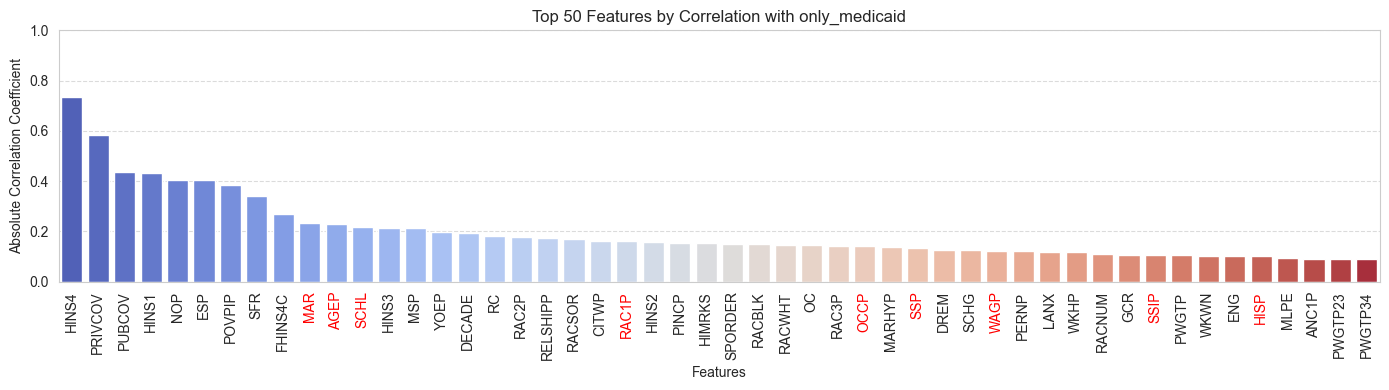

In [11]:
# Define numeric columns
numeric_cols = df_raw.select_dtypes(include=[np.number]).columns

# Calculate correlation of all numeric features with only_medicaid
corr_with_target = (
    df_raw[numeric_cols]
    .corrwith(df_raw['only_medicaid'])
    .abs()
    .sort_values(ascending=False)
)

# Remove target itself from the results
corr_with_target = corr_with_target.drop('only_medicaid', errors='ignore')

# Convert to DataFrame
corr_df = pd.DataFrame(corr_with_target, columns=['Correlation Coefficient'])

# Get top 50 features
top_50 = corr_df.head(50)

# Plot
plt.figure(figsize=(14, 4))
ax = sns.barplot(
    x=top_50.index,
    y=top_50['Correlation Coefficient'],
    palette='coolwarm'
)

plt.title('Top 50 Features by Correlation with only_medicaid')
plt.xlabel('Features')
plt.ylabel('Absolute Correlation Coefficient')
plt.ylim(0, 1)
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.7)

keep_set = set(keep_cols)
for label in ax.get_xticklabels():
    if label.get_text().strip() in keep_set:
        label.set_color('red')

plt.tight_layout()
plt.show()


*Note:* Some features show strong correlation with the target variable but are not included in the final modelling feature sets. Feature selection is guided by substantive and practical considerations and is discussed in more detail in Section 2.1 (Feature Selection).

**Mutual Information:** We calculate mutual information scores between features and `only_medicaid` to capture non-linear dependencies and rank features by their overall predictive relevance.

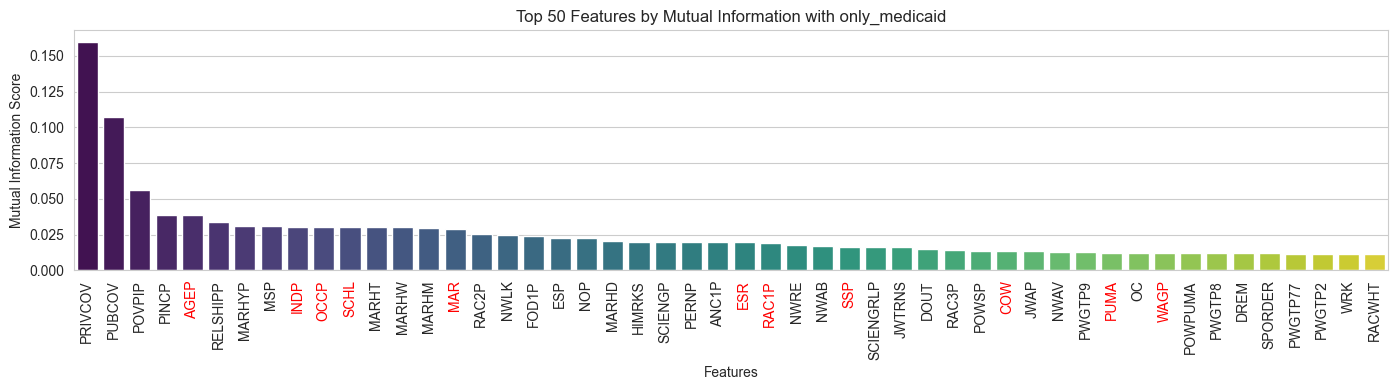

In [12]:
# Use a sample for speed
sample_df = df_raw.sample(min(5000, len(df_raw)), random_state=42).fillna(0)

# Define X and y for mutual information
drop_cols = ['only_medicaid'] + [c for c in sample_df.columns if c.startswith('HINS')]
X_mi = sample_df.select_dtypes(include=[np.number]).drop(columns=drop_cols, errors='ignore')
y_mi = sample_df['only_medicaid']

# Mutual information
mi = mutual_info_classif(X_mi, y_mi, random_state=42)
mi_series = pd.Series(mi, index=X_mi.columns).sort_values(ascending=False)

# Plot TOP 50 Mutual Information scores
plt.figure(figsize=(14, 4))
top_50_mi = mi_series.head(50)

ax = sns.barplot(x=top_50_mi.index, y=top_50_mi.values, palette='viridis')

plt.title('Top 50 Features by Mutual Information with only_medicaid')
plt.xlabel('Features')
plt.ylabel('Mutual Information Score')
plt.xticks(rotation=90)

# Highlight selected features
keep_set = set(keep_cols)
for label in ax.get_xticklabels():
    if label.get_text().strip() in keep_set:
        label.set_color('red')

plt.tight_layout()
plt.show()

*Note:* Some features show strong mutual information with the target variable but are not included in the final modelling feature sets. Feature selection is guided by substantive and practical considerations and is discussed in more detail in Section 2.1 (Feature Selection).

---

## 2. Data Cleaning and Feature Engineering

After exploring the initial dataset, we now transform the raw data into model-ready feature sets through a structured cleaning and engineering process.

> *Section 2.1 reduces the dataset to only the features relevant for modelling, while Section 2.2 focuses on data cleaning, handling missing values, and ensuring data consistency. Section 2.3 constructs the target variable and engineers additional features to create a fully processed modelling dataframe. Finally, Section 2.4 generates different feature subsets for comparison: a **Statistical (Baseline)** set with all features for upper-bound performance, a **Realistic** set with only publicly accessible or inferable information, and a **Business** set containing richer attributes an insurer would already know.*


### 2.1 Feature Selection

First, we filter the dataset to retain only the most relevant features for our analysis, grouped by domain. This step reduces dimensionality and focuses the model on impactful variables. The features in the Target Group will later be used to engineer _one_ target variable (`only_medicaid`).

**Kept Features:**
- **Group 1 (Income & Affordability):** `WAGP`, `SEMP`, `INTP`, `RETP`, `SSP`, `SSIP`, `PAP`
- **Group 2 (Employment Quality):** `ESR`, `COW`, `WKL`, `OCCP`, `INDP`
- **Group 3 (Demographics):** `AGEP`, `SEX`, `MAR`, `MIG`, `NATIVITY`, `RAC1P`, `HISP`
- **Group 4 (Education):** `SCHL`, `SCH`
- **Group 5 (Health & Disability):** `DIS`, `DEAR`, `DEYE`, `DPHY`
- **Group 6 (Geography):** `STATE`, `PUMA`
- **Target Group (Health Insurance Indicators):** `HINS4`, `HINS1`, `HINS2`, `HINS3`, `HINS5`, `HINS6`, `HINS7`

In [13]:
keep_cols = [
    # Income & Affordability
    'WAGP', 'SEMP', 'INTP', 'RETP', 'SSP', 'SSIP', 'PAP',
    # Employment Quality
    'ESR', 'COW', 'WKL', 'OCCP', 'INDP',
    # Demographics
    'AGEP', 'SEX', 'MAR', 'MIG', 'NATIVITY', 'RAC1P', 'HISP',
    # Education
    'SCHL', 'SCH',
    # Health & Disability
    'DIS', 'DEAR', 'DEYE', 'DPHY',
    # Geography
    'STATE', 'PUMA',
    # Health Insurance Indicators
    'HINS4', 'HINS1', 'HINS2', 'HINS3', 'HINS5', 'HINS6', 'HINS7',
]

existing_cols = [c for c in keep_cols if c in df_raw.columns]
dropped_cols = len(df_raw.columns) - len(existing_cols)

df_2_1 = df_raw[existing_cols]
print(f"Retained {len(existing_cols)} features. Dropped {dropped_cols} features.")

Retained 34 features. Dropped 254 features.


### 2.2 Data Cleaning

We further reduce the dataset to include only individuals between the ages of 18 and 65, as this is the relevant population for our analysis.

In [14]:
df_2_2 = df_2_1.copy()

if 'AGEP' in df_2_2.columns:
    initial_count = len(df_2_2)
    df_2_2 = df_2_2[(df_2_2['AGEP'] >= 18) & (df_2_2['AGEP'] <= 65)]
    print(f"Dropped {initial_count - len(df_2_2)} rows outside age range.")

Dropped 63362 rows outside age range.


We then apply imputations for the features `OCCP` (Occupation Code), `INDP` (Industry Code), and `COW` (Class of Worker). If any of these values are missing, we impute them with the corresponding code for "unemployed."

In [15]:
# Imputations for OCCP and INDP
for col in ['OCCP', 'INDP']:
    if col in df_2_2.columns:
        n_missing = df_2_2[col].isna().sum()
        df_2_2[col] = df_2_2[col].fillna(9920)
        print(f"Imputed {n_missing} missing values in '{col}' with code 9920 (unemployed).")

# Imputations for COW
if 'COW' in df_2_2.columns:
    n_missing = df_2_2['COW'].isna().sum()
    df_2_2['COW'] = df_2_2['COW'].fillna(9)
    print(f"Imputed {n_missing} missing values in 'COW' with code 9 (unemployed).")


Imputed 10154 missing values in 'OCCP' with code 9920 (unemployed).
Imputed 10154 missing values in 'INDP' with code 9920 (unemployed).
Imputed 10154 missing values in 'COW' with code 9 (unemployed).


Lastly, we perform a final check for remaining missing values to ensure data consistency before moving on to feature engineering.

In [16]:
missing = df_2_2.isnull().sum()
missing = missing[missing > 0]

if not missing.empty:
    print(f"\nFound {len(missing)} columns with missing values.")
    missing_pct = (missing / len(df_2_2)) * 100
    missing_report = pd.DataFrame({'Missing Count': missing, 'Percentage': missing_pct})
    print(missing_report.sort_values('Percentage', ascending=False).head(10))
else:
    print("\nNo missing values found.")


No missing values found.


In [17]:
print(f"Data Shape: {df_2_2.shape[0]} rows, {df_2_2.shape[1]} columns")
display(df_2_2.head(3))

Data Shape: 95533 rows, 34 columns


,WAGP,SEMP,INTP,RETP,SSP,SSIP,PAP,ESR,COW,WKL,...,DPHY,STATE,PUMA,HINS4,HINS1,HINS2,HINS3,HINS5,HINS6,HINS7
0,12000.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,...,2.0,33,301,2,1,2,2,2,2,2
4,5000.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,3.0,1.0,...,2.0,33,501,2,2,1,2,2,2,2
5,2600.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,4.0,1.0,...,2.0,33,501,2,1,2,2,2,2,2


### 2.3 Feature Engineering
We create a new dataframe with additional engineered features. This involves binning continuous variables and creating simplified categories.

**Target Variable:** First, we create the target variable `only_medicaid` based on insurance indicators and then drop all original `HINS` columns. We want to predict, whether an individual is insured *only* with Medicaid, and no other insurance type.

In [18]:
df_2_3 = df_2_2.copy()

insurance = ["HINS1","HINS2","HINS3","HINS5","HINS6","HINS7"]

df_2_3["only_medicaid"] = np.where(
    (df_2_3["HINS4"] == 1) & df_2_3[insurance].eq(2).all(axis=1),
    1,
    0
)

df_2_3 = df_2_3.drop(columns=[c for c in df_2_3.columns if c.startswith("HINS")])

target = 'only_medicaid' # save as variable 'target' for function calls later

**Group 1 (Income & Affordability):** We introduce the feature `income_group` by binning continuous income, add the boolean variable `has_wage_income`, create `income_source_count` to capture how many income sources an individual has, and add `has_self_employment` to indicate self-employment income.

In [19]:
# income_group
if 'WAGP' in df_2_3.columns:
    bins = [-1, 15000, 30000, 50000, 75000, np.inf]
    labels = ['Very_Low', 'Low', 'Medium', 'High', 'Very_High']
    df_2_3['income_group'] = pd.cut(df_2_3['WAGP'], bins=bins, labels=labels)

# has_wage_income
if 'WAGP' in df_2_3.columns:
    df_2_3['has_wage_income'] = (df_2_3['WAGP'] > 0).astype(int)
    
# income_source_count
income_cols = ['WAGP','SEMP','INTP','RETP','SSP','SSIP','PAP']
avail_inc_cols = [c for c in income_cols if c in df_2_3.columns]
if avail_inc_cols:
    df_2_3['income_source_count'] = (df_2_3[avail_inc_cols] > 0).sum(axis=1)

# has_self_employment
if 'SEMP' in df_2_3.columns:
    df_2_3['has_self_employment'] = (df_2_3['SEMP'] > 0).astype(int)

**Group 2 (Employment Quality):** We create `employment_status_simple` to group detailed labor-force categories into broader employment states, introduce `employer_type` to classify the type of employer, and derive `OCCP_2digit` and `INDP_2digit` to convert detailed occupation and industry codes into more general two-digit categories.

In [20]:
# employment_status_simple
if 'ESR' in df_2_3.columns:
    esr_mapping = {
        1: 'Employed', 2: 'Employed',
        3: 'Unemployed',
        4: 'Not_in_labor_force', 5: 'Not_in_labor_force', 6: 'Not_in_labor_force'
    }
    df_2_3['employment_status_simple'] = df_2_3['ESR'].map(esr_mapping).fillna('Not_in_labor_force')

# employer_type
if 'COW' in df_2_3.columns:
    cow_mapping = {
        1: 'Private', 2: 'Private',
        3: 'Government', 4: 'Government', 5: 'Government',
        6: 'Self_employed', 7: 'Self_employed',
        8: 'Unpaid', 9: 'Unpaid'
    }
    df_2_3['employer_type'] = df_2_3['COW'].map(cow_mapping).fillna('Unknown')

# OCCP/INDP 2-digit conversion: Create derived features needed for selection
if 'OCCP' in df_2_3.columns:
    df_2_3['OCCP_2digit'] = df_2_3['OCCP'].fillna(0).astype(int).astype(str).str.zfill(4).str[:2]
if 'INDP' in df_2_3.columns:
    df_2_3['INDP_2digit'] = df_2_3['INDP'].fillna(0).astype(int).astype(str).str.zfill(4).str[:2]

**Group 3 (Demographics):** We create the feature `age_group` by binning individuals into age brackets and introduce `marital_status_simple` to consolidate detailed marital categories into broader, more informative groups.

In [21]:
# age_group
if 'AGEP' in df_2_3.columns:
    bins = [17, 25, 35, 45, 55, 65]
    labels = ['18-25', '26-35', '36-45', '46-55', '56-65']
    df_2_3['age_group'] = pd.cut(df_2_3['AGEP'], bins=bins, labels=labels)

# marital_status_simple
if 'MAR' in df_2_3.columns:
    mar_mapping = {
        1: 'Married',
        2: 'Divorced_Separated', 3: 'Divorced_Separated', 4: 'Divorced_Separated',
        5: 'Never_married'
    }
    df_2_3['marital_status_simple'] = df_2_3['MAR'].map(mar_mapping).fillna('Unknown')

**Group 4 (Education):** We create `education_level` by mapping detailed schooling codes into broader education categories and add `currently_enrolled` to indicate whether an individual is actively enrolled in school.

In [22]:
# education_level
if 'SCHL' in df_2_3.columns:
    def map_education(val):
        if pd.isna(val) or val == 0: return 'Unknown'
        if val <= 15: return 'Less_than_HS'
        if val <= 17: return 'HS_diploma'
        if val <= 20: return 'Some_college'
        if val == 21: return 'Bachelors'
        return 'Graduate'
    df_2_3['education_level'] = df_2_3['SCHL'].apply(map_education)

# currently_enrolled
if 'SCH' in df_2_3.columns:
    df_2_3['currently_enrolled'] = df_2_3['SCH'].isin([2, 3]).astype(int)

**Group 5 (Health & Disability):** We create the feature `has_any_disability` to indicate whether an individual reports any disability across the available disability-related indicators.

In [23]:
# has_any_disability
dis_cols = ['DIS', 'DEAR', 'DEYE', 'DPHY']
avail_dis_cols = [c for c in dis_cols if c in df_2_3.columns]
if avail_dis_cols:
    df_2_3['has_any_disability'] = (df_2_3[avail_dis_cols] == 1).any(axis=1).astype(int)

**Group 6 (Geography):** We standardize geographic information by creating the feature `STATE` when only the shorter code `ST` is available.

In [24]:
if 'ST' in df_2_3.columns and 'STATE' not in df_2_3.columns:
    df_2_3['STATE'] = df_2_3['ST']

The data cleaning and feature engineering steps are now complete, resulting in a processed dataframe that serves as the basis for creating the different feature subsets in the next step.

In [25]:
print(f"Data Shape: {df_2_3.shape[0]} rows, {df_2_3.shape[1]} columns")
display(df_2_3.head(3))

Data Shape: 95533 rows, 41 columns


,WAGP,SEMP,INTP,RETP,SSP,SSIP,PAP,ESR,COW,WKL,...,has_self_employment,employment_status_simple,employer_type,OCCP_2digit,INDP_2digit,age_group,marital_status_simple,education_level,currently_enrolled,has_any_disability
0,12000.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,...,0,Employed,Private,41,86,18-25,Never_married,Some_college,1,0
4,5000.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,3.0,1.0,...,0,Employed,Government,46,86,18-25,Never_married,Some_college,1,0
5,2600.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,4.0,1.0,...,0,Employed,Government,20,78,18-25,Never_married,HS_diploma,1,0


### 2.4 Create Feature Sets
We create 6 datasets with different feature sets for modeling to evaluate performance across different levels of data availability and complexity.

**Feature Sets:**
1. **Statistical (Baseline):** Includes all features to benchmark the model's best possible performance under ideal conditions.  
2. **Realistic:** Contains only features that could plausibly be obtained from publicly accessible or online-inferred data sources (e.g., demographics, social media signals).  
3. **Business:** Includes richer customer information available to an insurer through existing business relationships.
4.  **PCA Statistical:** The Statistical set reduced using Principal Component Analysis (PCA).
5.  **PCA Realistic:** The Realistic set reduced using PCA.
6.  **PCA Business:** The Business set reduced using PCA.

In [26]:
# Statistical (Baseline) Features - use all original columns from 2.1, excluding the new engineered ones from 2.3
engineered_cols = [
    'income_group', 'has_wage_income', 'income_source_count', 'poverty_band', 
    'has_self_employment', 'employment_status_simple', 'employer_type', 
    'age_group', 'marital_status_simple', 'education_level', 'currently_enrolled', 
    'has_any_disability'
]

# Realistic Feature Set
cols_realistic = [
    'income_group', 'has_wage_income', 'has_self_employment',
    'employment_status_simple', 'employer_type',
    'SEX', 'age_group', 'marital_status_simple',
    'education_level', 'currently_enrolled',
    'STATE', 'PUMA'
]

# Business Features Set
cols_business = [
    'WAGP_normalized', 'SEMP', 'income_source_count', 'has_wage_income', 'has_self_employment',
    'WKL', 'OCCP_2digit', 'INDP_2digit', 'employment_status_simple', 'employer_type',
    'AGEP', 'SEX', 'MAR', 'MIG', 'NATIVITY', 'RAC1P', 'HISP', 'age_group', 'marital_status_simple',
    'education_level', 'currently_enrolled', 'has_any_disability',
    'STATE', 'PUMA'
]

We define two helper functions, `preprocess_set()` and `apply_pca()`, to streamline repeated preprocessing steps across all feature sets.

In `preprocess_set()`, we (1) select all valid columns from the specified feature list, (2) separate the target variable, (3) identify and one-hot encode categorical features, (4) standardize all encoded features, and (5) remove highly collinear features using an absolute Pearson correlation threshold of 0.95, computed on standardized features.

In [27]:
def preprocess_set(df_subset, col_list, set_name):
    # Filter columns that exist in the dataframe
    valid_cols = [c for c in col_list if c in df_subset.columns]

        
    X = df_subset[valid_cols].copy()
    y = df_subset[target]
    
    # Identify types
    cat_cols = X.select_dtypes(include=['object', 'category']).columns
            
    # One-Hot Encoding
    X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True)
    
    # Standard Scaling
    scaler = StandardScaler()
    X_scaled = pd.DataFrame(scaler.fit_transform(X_encoded), columns=X_encoded.columns, index=X_encoded.index)
    
    corr_matrix = X_scaled.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop = [column for column in upper.columns if any(upper[column] > 0.95)]
    X_final = X_scaled.drop(columns=to_drop)
    #print(f"Dropped {len(to_drop)} collinear features: {to_drop}")
        
    return X_final, y

In `apply_pca()`, we (1) validate that the input matrix is non-empty, (2) adjust the requested number of components if it exceeds allowable dimensions, (3) apply PCA to reduce the feature space while preserving at least 95% of the variance (or the specified threshold), and (4) return the transformed components as a new DataFrame, falling back to the original data if PCA fails.

In [28]:
def apply_pca(X, n_components=0.5):
    if X.empty or X.shape[1] == 0:
        print("  -> Warning: Input to PCA is empty. Returning empty DataFrame.")
        return pd.DataFrame(index=X.index)
        
    # Ensure n_components is valid
    n_samples, n_features = X.shape
    if n_components > min(n_samples, n_features):
            n_components = min(n_samples, n_features)
            
    pca = PCA(n_components=n_components)
    try:
        X_pca = pca.fit_transform(X)
        cols = [f'PC{i+1}' for i in range(X_pca.shape[1])]
        return pd.DataFrame(X_pca, columns=cols, index=X.index)
    except Exception as e:
        print(f"  -> PCA Failed: {e}")
        return X # Fallback to original if PCA fails

We now generate six feature sets using `create_feature_sets()`: three base sets (Statistical, Realistic, and Business) that reflect different levels of information availability, along with their corresponding PCA-reduced versions. Each set is preprocessed consistently and stored in the `feature_sets` dictionary to enable systematic comparison during model training.

In [29]:
def create_feature_sets(df_input, cols_realistic, cols_business, engineered_cols):
    df = df_input.copy()
    
    if target not in df.columns:
        print(f"Error: Target {target} not found.")
        return {}

    cols_statistical = [c for c in df.columns if c not in engineered_cols and c != target]
    feature_sets = {}

    # 1. Statistical
    # X_stat, y_stat = preprocess_set(df, cols_statistical, "Statistical")
    # feature_sets['Statistical'] = (X_stat, y_stat)

    # 2. Business
    X_bus, y_bus = preprocess_set(df, cols_business, "Business")
    feature_sets['Business'] = (X_bus, y_bus)

    # 3. Realistic
    X_real, y_real = preprocess_set(df, cols_realistic, "Realistic")
    feature_sets['Realistic'] = (X_real, y_real)



    # 4. PCA Statistical
    # X_pca_stat = apply_pca(X_stat)
    # feature_sets['PCA_Statistical'] = (X_pca_stat, y_stat)

    # 5. PCA Business
    X_pca_bus = apply_pca(X_bus)
    feature_sets['PCA_Business'] = (X_pca_bus, y_bus)

    # 6. PCA Realistic
    X_pca_real = apply_pca(X_real)
    feature_sets['PCA_Realistic'] = (X_pca_real, y_real)

    return feature_sets


if 'df_2_3' in locals():
    feature_sets = create_feature_sets(df_2_3, cols_realistic, cols_business, engineered_cols) # We use df_2_3 (Engineered, Pre-Encoding) as the base to allow for specific feature selection
    
    # Display shapes
    # print("\nSummary of Feature Sets:")
    for name, (X, y) in feature_sets.items():
        print(f"{name:<15}: {X.shape[1]} features, {X.shape[0]} rows")

Business       : 222 features, 95533 rows
Realistic      : 25 features, 95533 rows
PCA_Business   : 79 features, 95533 rows
PCA_Realistic  : 7 features, 95533 rows


*Note:* The **Statistical** and **Business** feature sets contain a large number of features (200+ columns) because categorical variables are expanded into multiple dummy variables during one-hot encoding. This reflects the high dimensionality of these richer feature sets prior to dimensionality reduction.

---

## 3. Modelling

In this section, we train and compare multiple machine learning models across the different feature sets.

> *Section 3.1 describes how the data is split into training and test sets to ensure a fair evaluation of model performance. Section 3.2 covers the training of multiple machine learning models across the different feature sets, including logistic regression, tree-based methods, gradient boosting models, and a neural network. Finally, Section 3.3 compares the trained models using consistent performance metrics to identify the most suitable model–feature set combination for the task.*

### 3.1 Data Splitting

Each feature set is split into training, validation, and test sets using a stratified approach (70% / 15% / 15%) to preserve the class distribution of the target variable across all splits. A fixed random seed is used to randomly shuffle the data to avoid potential biases that could arise if the dataset were ordered by insurance status or other factors, while ensuring reproducible results.

randomize!

In [30]:
def split_dataset(X, y, test_size=0.15, val_size=0.15, random_state=42):
    """
    Splits data into Train, Validation, and Test sets with stratification.
    """
    temp_size = val_size + test_size
    
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, test_size=temp_size, stratify=y, random_state=random_state
    )
    
    val_split_ratio = val_size / temp_size
    
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp,
        test_size=(1 - val_split_ratio),
        stratify=y_temp,
        random_state=random_state
    )
    
    return X_train, X_val, X_test, y_train, y_val, y_test


data_splits = {}

for set_name, (X, y) in feature_sets.items():
    X_train, X_val, X_test, y_train, y_val, y_test = split_dataset(X, y)
    
    data_splits[set_name] = {
        'X_train': X_train, 'y_train': y_train,
        'X_val': X_val, 'y_val': y_val,
        'X_test': X_test, 'y_test': y_test
    }


# Print split summary once (same for all feature sets)
any_set = next(iter(data_splits.values()))
n_total = (
    any_set['X_train'].shape[0]
    + any_set['X_val'].shape[0]
    + any_set['X_test'].shape[0]
)

print(
    f"Data split (identical across all feature sets): "
    f"Train = {any_set['X_train'].shape[0]} rows, "
    f"Validation = {any_set['X_val'].shape[0]} rows, "
    f"Test = {any_set['X_test'].shape[0]} rows "
    f"({n_total} total rows)."
)

Data split (identical across all feature sets): Train = 66873 rows, Validation = 14330 rows, Test = 14330 rows (95533 total rows).


### Apply SMOTE to Training Sets

In [31]:
for set_name, splits in data_splits.items():
    print(f"\nProcessing {set_name}...")
    
    X_train_orig = splits['X_train']
    y_train_orig = splits['y_train']
    
    # Initialize SMOTE
    smote = SMOTE(random_state=42)
    
    # Fit and resample ONLY the training data
    X_train_res, y_train_res = smote.fit_resample(X_train_orig, y_train_orig)
    
    # Update the dictionary with the new balanced training data
    data_splits[set_name]['X_train'] = X_train_res
    data_splits[set_name]['y_train'] = y_train_res
    
    # Print stats as Percentages
    orig_dist = y_train_orig.value_counts(normalize=True).mul(100).round(2).to_dict()
    res_dist = y_train_res.value_counts(normalize=True).mul(100).round(2).to_dict()
    
    # Print stats
    print(f"  Original class dist : {orig_dist}")
    print(f"  Resampled class dist: {res_dist}")
    print(f"  New Train Shape     : {X_train_res.shape}")


Processing Business...
  Original class dist : {0: 87.47, 1: 12.53}
  Resampled class dist: {0: 50.0, 1: 50.0}
  New Train Shape     : (116982, 222)

Processing Realistic...
  Original class dist : {0: 87.47, 1: 12.53}
  Resampled class dist: {0: 50.0, 1: 50.0}
  New Train Shape     : (116982, 25)

Processing PCA_Business...
  Original class dist : {0: 87.47, 1: 12.53}
  Resampled class dist: {0: 50.0, 1: 50.0}
  New Train Shape     : (116982, 79)

Processing PCA_Realistic...
  Original class dist : {0: 87.47, 1: 12.53}
  Resampled class dist: {0: 50.0, 1: 50.0}
  New Train Shape     : (116982, 7)


### 3.2 Model Training


In [32]:
def train_and_tune(model, param_grid, X_train, y_train, X_val, y_val, model_name, dataset_name):
    print(f"Training {model_name} on {dataset_name}...")
    
    start_time = time.time()
    
    # Use GridSearchCV
    grid_search = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        cv=7,
        scoring='average_precision',
        n_jobs=-1,
        verbose=0
    )
    
    grid_search.fit(X_train, y_train)
    
    end_time = time.time()
    training_time = end_time - start_time
    
    best_model = grid_search.best_estimator_
    best_params = grid_search.best_params_
    
    # Evaluate on Validation Set
    y_pred = best_model.predict(X_val)
    y_prob = best_model.predict_proba(X_val)[:, 1] if hasattr(best_model, "predict_proba") else y_pred
    
    val_accuracy = accuracy_score(y_val, y_pred)
    val_pr_auc = average_precision_score(y_val, y_prob)
    val_roc_auc = roc_auc_score(y_val, y_prob)

    # Evaluate on Training Set
    y_train_pred = best_model.predict(X_train)
    y_train_prob = best_model.predict_proba(X_train)[:, 1] if hasattr(best_model, "predict_proba") else y_train_pred
    train_pr_auc = average_precision_score(y_train, y_train_prob)
    
    print(f"  -> Best Params: {best_params}")
    print(f"  -> Val PR-AUC: {val_pr_auc:.4f}")
    print(f"  -> Train PR-AUC: {train_pr_auc:.4f}")
    print(f"  -> Training Time: {training_time:.2f} seconds")
    
    return {
        'Model': model_name,
        'Dataset': dataset_name,
        'Best_Params': best_params,
        'Val_Accuracy': val_accuracy,
        'Val_PR_AUC': val_pr_auc,
        'Val_ROC_AUC': val_roc_auc,
        'Train_PR_AUC': train_pr_auc,
        'Training_Time': training_time,
        'Model_Instance': best_model
    }

# Store all results
all_results = []

#### 3.2.1 Logistic Regression
We train Logistic Regression models across all feature sets, tuning regularization strength (`C`) and penalty type.

In [33]:
lr_params = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l2'],
    'solver': ['lbfgs'],
    'max_iter': [1000]
}

if 'data_splits' in locals():
    for set_name, splits in data_splits.items():
        res = train_and_tune(
            LogisticRegression(random_state=42),
            lr_params,
            splits['X_train'], splits['y_train'],
            splits['X_val'], splits['y_val'],
            "LogisticRegression", set_name
        )
        all_results.append(res)

Training LogisticRegression on Business...
  -> Best Params: {'C': 0.1, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'lbfgs'}
  -> Val PR-AUC: 0.4024
  -> Train PR-AUC: 0.8133
  -> Training Time: 33.45 seconds
Training LogisticRegression on Realistic...
  -> Best Params: {'C': 0.01, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'lbfgs'}
  -> Val PR-AUC: 0.4238
  -> Train PR-AUC: 0.8206
  -> Training Time: 2.61 seconds
Training LogisticRegression on PCA_Business...
  -> Best Params: {'C': 0.01, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'lbfgs'}
  -> Val PR-AUC: 0.3646
  -> Train PR-AUC: 0.7834
  -> Training Time: 7.96 seconds
Training LogisticRegression on PCA_Realistic...
  -> Best Params: {'C': 0.01, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'lbfgs'}
  -> Val PR-AUC: 0.2962
  -> Train PR-AUC: 0.7379
  -> Training Time: 0.82 seconds


#### 3.2.2 Random Forest
We train Random Forest models, tuning the number of trees (`n_estimators`) and maximum depth (`max_depth`) to control overfitting.

In [34]:
rf_params = {
    'n_estimators': [200],
    'max_depth': [3, 5],
    'min_samples_split': [10, 20, 50]
}

if 'data_splits' in locals():
    for set_name, splits in data_splits.items():
        res = train_and_tune(
            RandomForestClassifier(random_state=42),
            rf_params,
            splits['X_train'], splits['y_train'],
            splits['X_val'], splits['y_val'],
            "RandomForest", set_name
        )
        all_results.append(res)

Training RandomForest on Business...
  -> Best Params: {'max_depth': 5, 'min_samples_split': 10, 'n_estimators': 200}
  -> Val PR-AUC: 0.3842
  -> Train PR-AUC: 0.8929
  -> Training Time: 65.34 seconds
Training RandomForest on Realistic...
  -> Best Params: {'max_depth': 5, 'min_samples_split': 50, 'n_estimators': 200}
  -> Val PR-AUC: 0.3908
  -> Train PR-AUC: 0.8290
  -> Training Time: 35.54 seconds
Training RandomForest on PCA_Business...
  -> Best Params: {'max_depth': 5, 'min_samples_split': 50, 'n_estimators': 200}
  -> Val PR-AUC: 0.3623
  -> Train PR-AUC: 0.8028
  -> Training Time: 454.08 seconds
Training RandomForest on PCA_Realistic...
  -> Best Params: {'max_depth': 5, 'min_samples_split': 20, 'n_estimators': 200}
  -> Val PR-AUC: 0.3792
  -> Train PR-AUC: 0.8001
  -> Training Time: 101.57 seconds


#### 3.2.3 XGBoost
We train XGBoost models, tuning learning rate, max depth, and the number of estimators. XGBoost is known for its efficiency and performance on structured data.

In [35]:
xgb_params = {
    "learning_rate": [0.05],  
    "n_estimators": [200],         
    "max_depth": [3],

    "min_child_weight": [5, 10],
    'gamma': [2,4],  
    "reg_alpha": [0.1, 0.5], 
    "reg_lambda": [2.0],


    "subsample": [0.8],                 
    "colsample_bytree": [0.8],      
    "tree_method": ["auto"],            
    "device": ["cuda"],                 
    "eval_metric": ["aucpr"],
}

if 'data_splits' in locals():
    for set_name, splits in data_splits.items():
        res = train_and_tune(
            XGBClassifier(use_label_encoder=False, random_state=42),
            xgb_params,
            splits['X_train'], splits['y_train'],
            splits['X_val'], splits['y_val'],
            "XGBoost", set_name
        )
        all_results.append(res)

Training XGBoost on Business...
  -> Best Params: {'colsample_bytree': 0.8, 'device': 'cuda', 'eval_metric': 'aucpr', 'gamma': 2, 'learning_rate': 0.05, 'max_depth': 3, 'min_child_weight': 10, 'n_estimators': 200, 'reg_alpha': 0.5, 'reg_lambda': 2.0, 'subsample': 0.8, 'tree_method': 'auto'}
  -> Val PR-AUC: 0.4216
  -> Train PR-AUC: 0.9682
  -> Training Time: 83.13 seconds
Training XGBoost on Realistic...
  -> Best Params: {'colsample_bytree': 0.8, 'device': 'cuda', 'eval_metric': 'aucpr', 'gamma': 4, 'learning_rate': 0.05, 'max_depth': 3, 'min_child_weight': 5, 'n_estimators': 200, 'reg_alpha': 0.5, 'reg_lambda': 2.0, 'subsample': 0.8, 'tree_method': 'auto'}
  -> Val PR-AUC: 0.4261
  -> Train PR-AUC: 0.9188
  -> Training Time: 19.73 seconds
Training XGBoost on PCA_Business...
  -> Best Params: {'colsample_bytree': 0.8, 'device': 'cuda', 'eval_metric': 'aucpr', 'gamma': 2, 'learning_rate': 0.05, 'max_depth': 3, 'min_child_weight': 10, 'n_estimators': 200, 'reg_alpha': 0.1, 'reg_lambda'

#### 3.2.4 Neural Network (MLP)
We train a Multi-Layer Perceptron (MLP), tuning the hidden layer sizes and activation functions to capture non-linear relationships.

In [36]:
mlp_params = {
    # Keep architectures small and few
    'hidden_layer_sizes': [
        (32,),
        (64, 32)
    ],
    
    # Stick to one activation for speed and stability
    'activation': ['relu'],
    
    # Small set of regularization values
    'alpha': [0.05],
    
    # Use adaptive to avoid wasting epochs
    'learning_rate': ['adaptive'],
    'learning_rate_init': [0.001],
    
    # One or two batch sizes max
    'batch_size': [64],
    
    # Cap iterations; early stopping will usually halt earlier anyway
    'max_iter': [300]
}


if 'data_splits' in locals():
    for set_name, splits in data_splits.items():
        res = train_and_tune(
            # Increase patience (n_iter_no_change) to avoid stopping too early
            MLPClassifier(random_state=42, early_stopping=True, n_iter_no_change=10),
            mlp_params,
            splits['X_train'], splits['y_train'],
            splits['X_val'], splits['y_val'],
            "NeuralNetwork", set_name
        )
        all_results.append(res)

Training NeuralNetwork on Business...
  -> Best Params: {'activation': 'relu', 'alpha': 0.05, 'batch_size': 64, 'hidden_layer_sizes': (64, 32), 'learning_rate': 'adaptive', 'learning_rate_init': 0.001, 'max_iter': 300}
  -> Val PR-AUC: 0.3935
  -> Train PR-AUC: 0.9711
  -> Training Time: 177.49 seconds
Training NeuralNetwork on Realistic...
  -> Best Params: {'activation': 'relu', 'alpha': 0.05, 'batch_size': 64, 'hidden_layer_sizes': (64, 32), 'learning_rate': 'adaptive', 'learning_rate_init': 0.001, 'max_iter': 300}
  -> Val PR-AUC: 0.4139
  -> Train PR-AUC: 0.9025
  -> Training Time: 76.46 seconds
Training NeuralNetwork on PCA_Business...
  -> Best Params: {'activation': 'relu', 'alpha': 0.05, 'batch_size': 64, 'hidden_layer_sizes': (64, 32), 'learning_rate': 'adaptive', 'learning_rate_init': 0.001, 'max_iter': 300}
  -> Val PR-AUC: 0.3854
  -> Train PR-AUC: 0.9194
  -> Training Time: 170.73 seconds
Training NeuralNetwork on PCA_Realistic...
  -> Best Params: {'activation': 'relu', 

### 3.2.5 Dummy Classifier
We train Dummy Classifier models across all feature sets, using the 'stratified' strategy to generate predictions based on the training set's class distribution.

In [37]:
dummy_params = {
    'strategy': ['stratified']
}

if 'data_splits' in locals():
    for set_name, splits in data_splits.items():
       
        # 2. Run Grid Search (using your helper function)
        # Note: This will run very fast as there is no "training"
        res = train_and_tune(
            model=DummyClassifier(random_state=42),
            param_grid=dummy_params,
            X_train=splits['X_train'],
            y_train=splits['y_train'],
            X_val=splits['X_val'],
            y_val=splits['y_val'],
            model_name="Dummy Classifier",
            dataset_name=set_name
        )
        if 'all_results' in locals():
            all_results.append(res)

Training Dummy Classifier on Business...
  -> Best Params: {'strategy': 'stratified'}
  -> Val PR-AUC: 0.1251
  -> Train PR-AUC: 0.4994
  -> Training Time: 8.12 seconds
Training Dummy Classifier on Realistic...
  -> Best Params: {'strategy': 'stratified'}
  -> Val PR-AUC: 0.1251
  -> Train PR-AUC: 0.4994
  -> Training Time: 0.84 seconds
Training Dummy Classifier on PCA_Business...
  -> Best Params: {'strategy': 'stratified'}
  -> Val PR-AUC: 0.1251
  -> Train PR-AUC: 0.4994
  -> Training Time: 2.64 seconds
Training Dummy Classifier on PCA_Realistic...
  -> Best Params: {'strategy': 'stratified'}
  -> Val PR-AUC: 0.1251
  -> Train PR-AUC: 0.4994
  -> Training Time: 0.34 seconds


### 3.3 Model Comparison
We aggregate the results from all models and feature sets to identify the best performing combination based on Validation ROC-AUC.

Top 10 Models by Validation PR-AUC:


,Model,Dataset,Val_PR_AUC
9,XGBoost,Realistic,0.426092
15,NeuralNetwork,PCA_Realistic,0.424029
1,LogisticRegression,Realistic,0.423779
8,XGBoost,Business,0.421641
13,NeuralNetwork,Realistic,0.413935
0,LogisticRegression,Business,0.402447
10,XGBoost,PCA_Business,0.400614
11,XGBoost,PCA_Realistic,0.398329
12,NeuralNetwork,Business,0.393511
5,RandomForest,Realistic,0.390756


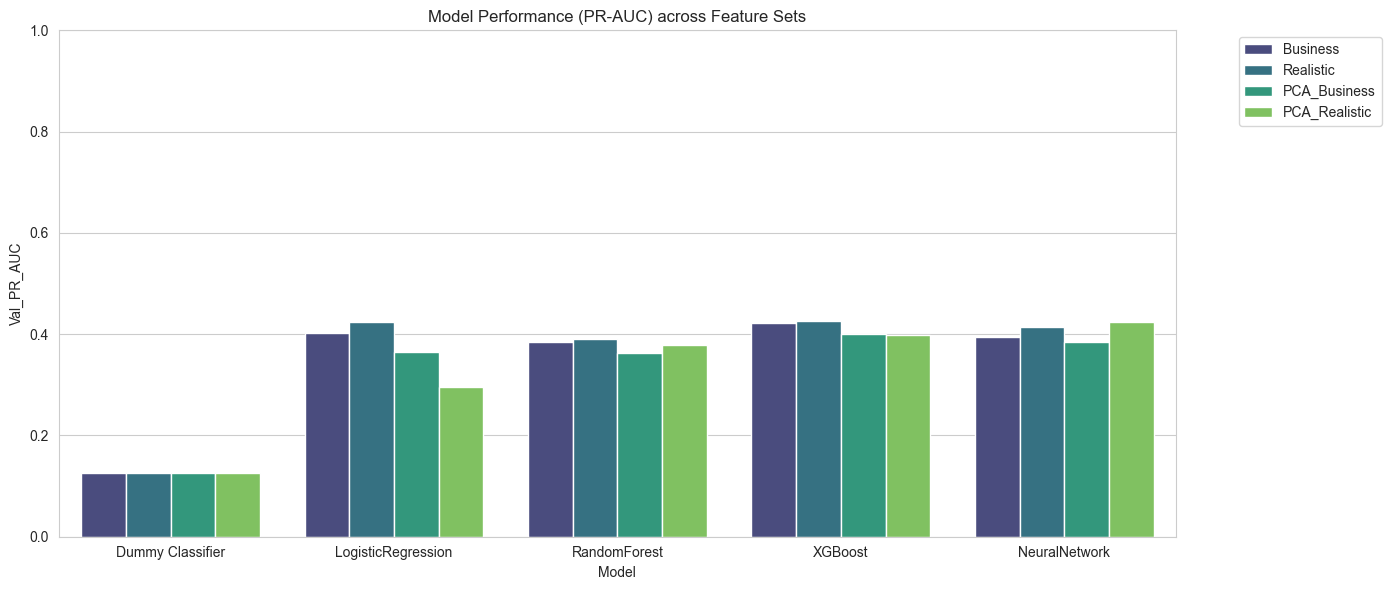

In [38]:
# Create Results DataFrame
results_df = pd.DataFrame(all_results)

if not results_df.empty:
    # 1. Deduplicate: Keep best run for each Model-Dataset combo
    # Sort by PR-AUC descending so the best is first
    results_df = results_df.sort_values('Val_PR_AUC', ascending=False)
    # Drop duplicates, keeping the first (best)
    results_df = results_df.drop_duplicates(subset=['Model', 'Dataset'], keep='first')

    # 2. Define Custom Order
    model_order = ['Dummy Classifier', 'LogisticRegression', 'RandomForest', 'XGBoost', 'NeuralNetwork']
    dataset_order = ['Business', 'Realistic', 'PCA_Business', 'PCA_Realistic']
    
    # Convert to Categorical for sorting/plotting
    results_df['Model'] = pd.Categorical(results_df['Model'], categories=model_order, ordered=True)
    results_df['Dataset'] = pd.Categorical(results_df['Dataset'], categories=dataset_order, ordered=True)
    
    # Sort by the custom order
    results_df = results_df.sort_values(['Model', 'Dataset'])
    
    print("Top 10 Models by Validation PR-AUC:")
    display(results_df[['Model', 'Dataset', 'Val_PR_AUC']].sort_values('Val_PR_AUC', ascending=False).head(10))
    
    # Visualization
    plt.figure(figsize=(14, 6))
    sns.barplot(data=results_df, x='Model', y='Val_PR_AUC', hue='Dataset', palette='viridis')
    plt.title('Model Performance (PR-AUC) across Feature Sets')
    plt.ylim(0, 1.0)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.tight_layout()
    plt.show()
else:
    print("No results to display.")

---

## 4. Evaluation
In this section, we analyze the performance of the 30 experimental combinations (5 Models $\times$ 6 Feature Sets). We start with a high-level overview to identify patterns, select the best performing model, and then perform a detailed evaluation on the held-out Test Set.

### 4.1 Performance Overview
We visualize the results to identify the top performers and understand how different feature sets impact model performance.

Calculating Test Performance...


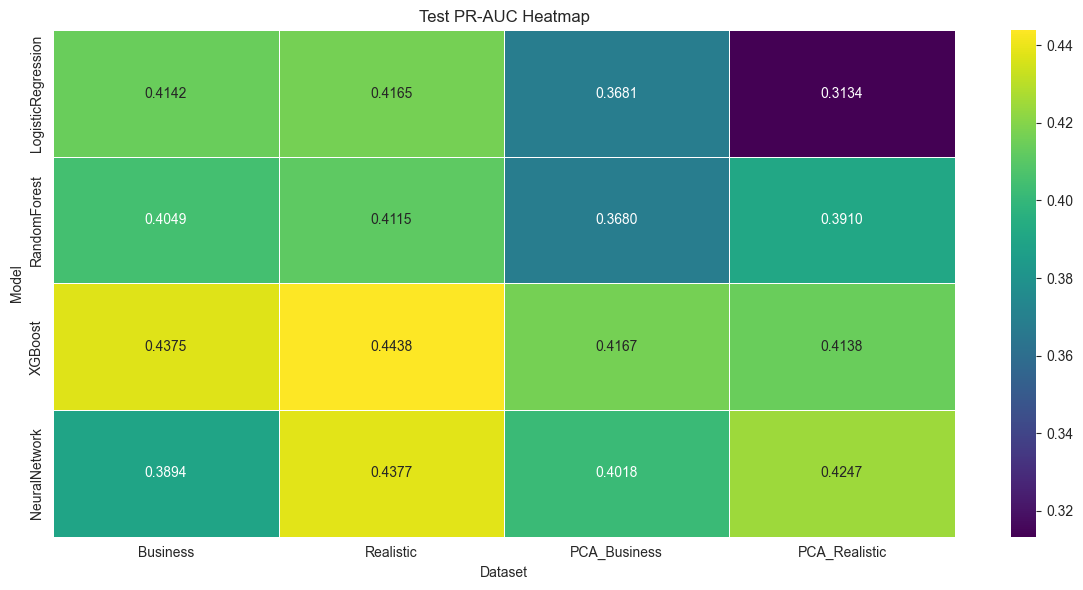

In [39]:
# Calculate Test Performance for all models
test_results = []

if 'all_results' in locals() and all_results:
    print("Calculating Test Performance...")
    for res in all_results:
        model_name = res['Model']
        dataset_name = res['Dataset']
        model_instance = res['Model_Instance']
        
        # Skip Dummy Classifier
        if model_name == 'Dummy Classifier':
            continue
            
        if dataset_name in data_splits:
            X_test_curr = data_splits[dataset_name]['X_test']
            y_test_curr = data_splits[dataset_name]['y_test']
            
            if hasattr(model_instance, "predict_proba"):
                y_prob = model_instance.predict_proba(X_test_curr)[:, 1]
            else:
                y_prob = model_instance.predict(X_test_curr)
                
            test_pr_auc = average_precision_score(y_test_curr, y_prob)
            
            test_results.append({
                'Model': model_name,
                'Dataset': dataset_name,
                'Test_PR_AUC': test_pr_auc
            })

    results_df = pd.DataFrame(test_results)

    if not results_df.empty:
        # Deduplicate: Keep best run for each Model-Dataset combo
        results_df = results_df.sort_values('Test_PR_AUC', ascending=False)
        results_df = results_df.drop_duplicates(subset=['Model', 'Dataset'], keep='first')

        # Define Custom Order
        model_order = ['LogisticRegression', 'RandomForest', 'XGBoost', 'NeuralNetwork']
        dataset_order = ['Statistical', 'Business', 'Realistic', 'PCA_Statistical', 'PCA_Business', 'PCA_Realistic']
        
        # Convert to Categorical for sorting/plotting
        results_df['Model'] = pd.Categorical(results_df['Model'], categories=model_order, ordered=True)
        results_df['Dataset'] = pd.Categorical(results_df['Dataset'], categories=dataset_order, ordered=True)
        
        # Pivot for Heatmap
        pivot_table = results_df.pivot_table(index='Model', columns='Dataset', values='Test_PR_AUC', aggfunc='mean')
        
        plt.figure(figsize=(12, 6))
        sns.heatmap(pivot_table, annot=True, fmt=".4f", cmap='viridis', linewidths=.5)
        plt.title('Test PR-AUC Heatmap')
        plt.tight_layout()
        plt.show()
    else:
        print("No results to display.")
else:
    print("No results found in 'all_results'.")

### 4.2 Cumulative Gain


Calculating Cumulative Gain for all models on Test Set...

--- Cumulative Gain Analysis (Gain@10%) ---


,Model,Dataset,Gain@10%,Gain@20%,Gain@30%
16,Dummy Classifier,Business,10.36%,19.43%,29.90%
17,Dummy Classifier,Realistic,10.36%,19.43%,29.90%
18,Dummy Classifier,PCA_Business,10.36%,19.43%,29.90%
19,Dummy Classifier,PCA_Realistic,10.36%,19.43%,29.90%
0,LogisticRegression,Business,37.31%,58.13%,73.61%
1,LogisticRegression,Realistic,37.64%,61.47%,74.11%
2,LogisticRegression,PCA_Business,33.35%,55.96%,69.88%
3,LogisticRegression,PCA_Realistic,30.35%,48.94%,62.53%
4,RandomForest,Business,35.75%,56.24%,68.43%
5,RandomForest,Realistic,36.53%,58.02%,71.99%


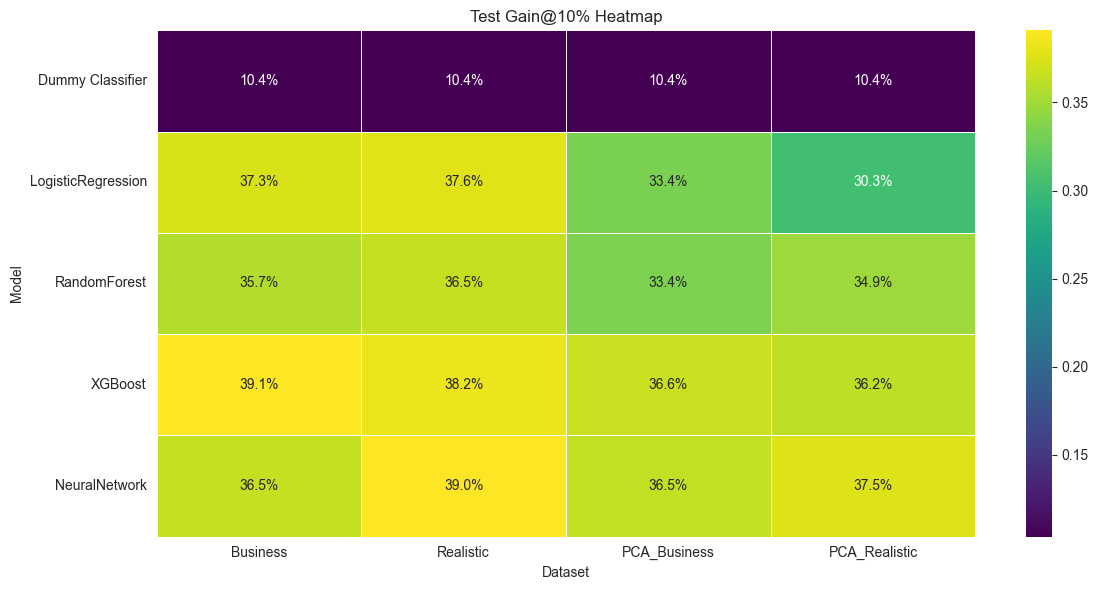

In [40]:
# Calculate Cumulative Gain for ALL models on Test Set
gain_results = []

if 'all_results' in locals() and all_results:
    print("Calculating Cumulative Gain for all models on Test Set...")
    
    for res in all_results:
        model_name = res['Model']
        dataset_name = res['Dataset']
        model_instance = res['Model_Instance']
        
        # Get Test Data
        if dataset_name in data_splits:
            X_test_curr = data_splits[dataset_name]['X_test']
            y_test_curr = data_splits[dataset_name]['y_test']
            
            # Predict Proba
            if hasattr(model_instance, "predict_proba"):
                y_prob = model_instance.predict_proba(X_test_curr)[:, 1]
            else:
                # For Dummy or models without predict_proba
                y_prob = model_instance.predict(X_test_curr)
            
            y_true = np.array(y_test_curr)

            # Sort by predicted probability (descending)
            sorted_indices = np.argsort(y_prob)[::-1]
            sorted_y_true = y_true[sorted_indices]

            # Calculate Cumulative Gain
            cum_positives = np.cumsum(sorted_y_true)
            total_positives = cum_positives[-1]
            
            if total_positives > 0:
                cum_gain = cum_positives / total_positives
                
                # Get indices for 10%, 20%, 30%
                n = len(cum_gain)
                idx_10 = max(0, int(0.1 * n) - 1)
                idx_20 = max(0, int(0.2 * n) - 1)
                idx_30 = max(0, int(0.3 * n) - 1)
                
                gain_results.append({
                    'Model': model_name,
                    'Dataset': dataset_name,
                    'Gain@10%': cum_gain[idx_10], 
                    'Gain@20%': cum_gain[idx_20],
                    'Gain@30%': cum_gain[idx_30]
                })

    # Create DataFrame
    if gain_results:
        gain_df = pd.DataFrame(gain_results)
        
        # Deduplicate: Keep best run for each Model-Dataset combo based on Gain@10%
        gain_df = gain_df.sort_values('Gain@10%', ascending=False)
        gain_df = gain_df.drop_duplicates(subset=['Model', 'Dataset'], keep='first')
        
        # Define Custom Order
        model_order = ['Dummy Classifier', 'LogisticRegression', 'RandomForest', 'XGBoost', 'NeuralNetwork']
        dataset_order = ['Statistical', 'Business', 'Realistic', 'PCA_Statistical', 'PCA_Business', 'PCA_Realistic']
        
        # Convert to Categorical
        gain_df['Model'] = pd.Categorical(gain_df['Model'], categories=model_order, ordered=True)
        gain_df['Dataset'] = pd.Categorical(gain_df['Dataset'], categories=dataset_order, ordered=True)
        
        # Sort
        gain_df = gain_df.sort_values(['Model', 'Dataset'])
        
        print("\n--- Cumulative Gain Analysis (Gain@10%) ---")
        # Apply formatting only to numeric columns
        display(gain_df[['Model', 'Dataset', 'Gain@10%', 'Gain@20%', 'Gain@30%']].style.format({
            'Gain@10%': '{:.2%}',
            'Gain@20%': '{:.2%}',
            'Gain@30%': '{:.2%}'
        }))
        
        # Visualization (Heatmap of Gain@10%)
        pivot_table = gain_df.pivot_table(index='Model', columns='Dataset', values='Gain@10%', aggfunc='mean')
        
        plt.figure(figsize=(12, 6))
        sns.heatmap(pivot_table, annot=True, fmt=".1%", cmap='viridis', linewidths=.5)
        plt.title('Test Gain@10% Heatmap')
        plt.tight_layout()
        plt.show()
        
    else:
        print("No models supported predict_proba or no positive cases found.")
        
else:
    print("No results found in 'all_results'.")

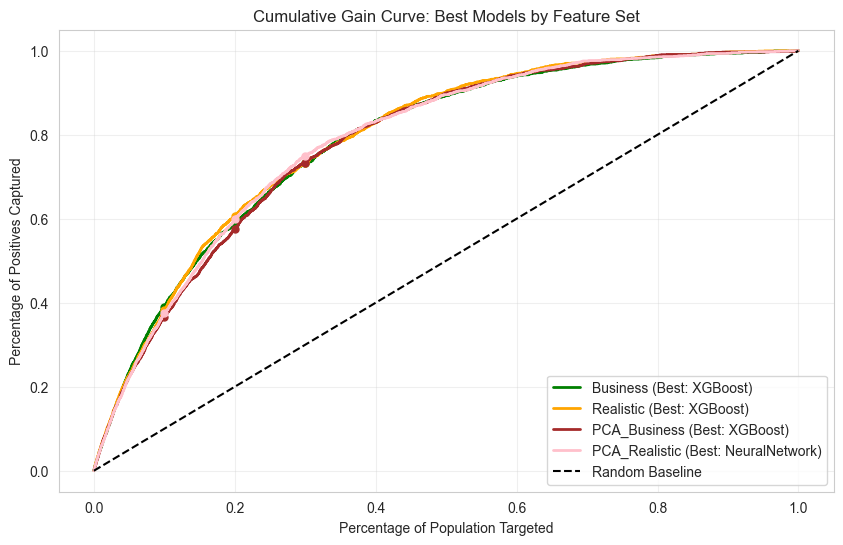

In [41]:
# Plot Cumulative Gain for Best Models per Dataset Type
if 'all_results' in locals() and all_results:
    plt.figure(figsize=(10, 6))
    
    # Define the datasets we want to compare
    target_datasets = [ 'Business', 'Realistic', 'PCA_Business', 'PCA_Realistic']
    colors = {'Business': 'green', 'Realistic': 'orange', 'PCA_Business': 'brown', 'PCA_Realistic': 'pink'}
    
    # Find best model for each target dataset based on PR-AUC
    best_models = {}
    for ds in target_datasets:
        ds_results = [r for r in all_results if r['Dataset'] == ds]
        if ds_results:
            # Sort by PR-AUC and pick top 1
            best_model_entry = sorted(ds_results, key=lambda x: x['Val_PR_AUC'], reverse=True)[0]
            best_models[ds] = best_model_entry

    # Plot curves
    for ds_name, entry in best_models.items():
        model_instance = entry['Model_Instance']
        model_name = entry['Model']
        
        if dataset_name in data_splits:
            X_test_curr = data_splits[ds_name]['X_test']
            y_test_curr = data_splits[ds_name]['y_test']
            
            if hasattr(model_instance, "predict_proba"):
                y_prob = model_instance.predict_proba(X_test_curr)[:, 1]
                y_true = np.array(y_test_curr)
                
                # Sort
                sorted_indices = np.argsort(y_prob)[::-1]
                sorted_y_true = y_true[sorted_indices]
                
                # Cumulative Gain
                cum_positives = np.cumsum(sorted_y_true)
                total_positives = cum_positives[-1]
                
                if total_positives > 0:
                    cum_gain = cum_positives / total_positives
                    x_axis = np.arange(1, len(cum_gain) + 1) / len(cum_gain)
                    
                    # Plot line
                    label_str = f"{ds_name} (Best: {model_name})"
                    plt.plot(x_axis, cum_gain, label=label_str, color=colors.get(ds_name, 'gray'), linewidth=2)
                    
                    # Add markers at 10%, 20%, 30%
                    for pct in [0.1, 0.2, 0.3]:
                        idx = int(pct * len(cum_gain)) - 1
                        plt.plot(x_axis[idx], cum_gain[idx], marker='o', color=colors.get(ds_name, 'gray'), markersize=5)

    # Random Baseline
    plt.plot([0, 1], [0, 1], 'k--', label='Random Baseline')
    
    plt.title('Cumulative Gain Curve: Best Models by Feature Set')
    plt.xlabel('Percentage of Population Targeted')
    plt.ylabel('Percentage of Positives Captured')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print("No results found.")

### 4.3 Best Models Lift Caluculation


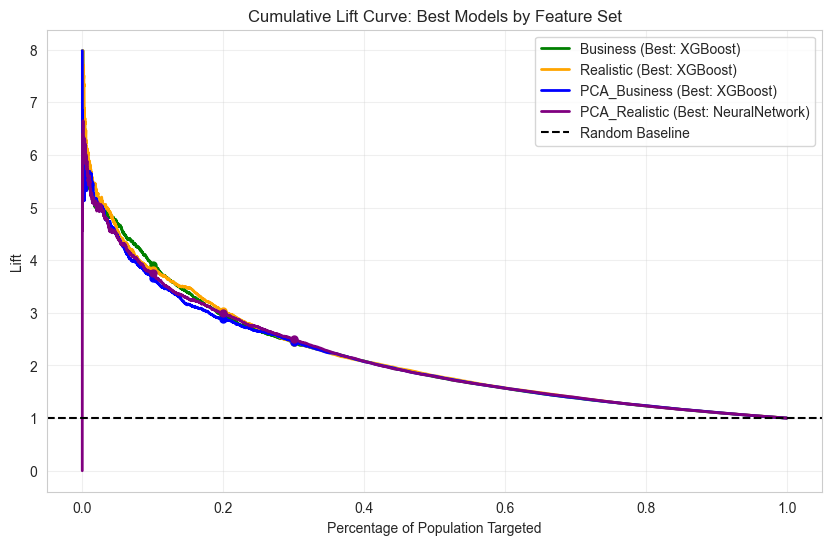

In [42]:
# Plot Cumulative Lift for Best Models per Dataset Type
if 'all_results' in locals() and all_results:
    plt.figure(figsize=(10, 6))
    
    # Define the datasets we want to compare
    target_datasets = [ 'Business', 'Realistic', 'PCA_Business', 'PCA_Realistic']
    colors = {'Business': 'green', 'Realistic': 'orange', 'PCA_Business': 'blue', 'PCA_Realistic': 'purple'}
    
    # Find best model for each target dataset based on PR-AUC
    best_models = {}
    for ds in target_datasets:
        ds_results = [r for r in all_results if r['Dataset'] == ds]
        if ds_results:
            # Sort by PR-AUC and pick top 1
            best_model_entry = sorted(ds_results, key=lambda x: x['Val_PR_AUC'], reverse=True)[0]
            best_models[ds] = best_model_entry

    # Plot curves
    for ds_name, entry in best_models.items():
        model_instance = entry['Model_Instance']
        model_name = entry['Model']
        
        # Ensure we use the correct key from the loop
        if ds_name in data_splits:
            X_test_curr = data_splits[ds_name]['X_test']
            y_test_curr = data_splits[ds_name]['y_test']
            
            if hasattr(model_instance, "predict_proba"):
                y_prob = model_instance.predict_proba(X_test_curr)[:, 1]
                y_true = np.array(y_test_curr)
                
                # Sort by predicted probability descending
                sorted_indices = np.argsort(y_prob)[::-1]
                sorted_y_true = y_true[sorted_indices]
                
                # Calculate Cumulative Gain
                cum_positives = np.cumsum(sorted_y_true)
                total_positives = cum_positives[-1]
                
                if total_positives > 0:
                    cum_gain = cum_positives / total_positives
                    # Percentage of population (x-axis)
                    x_axis = np.arange(1, len(cum_gain) + 1) / len(cum_gain)
                    
                    # Calculate Lift: Gain / % Population
                    lift = cum_gain / x_axis
                    
                    # Plot line
                    label_str = f"{ds_name} (Best: {model_name})"
                    plt.plot(x_axis, lift, label=label_str, color=colors.get(ds_name, 'gray'), linewidth=2)
                    
                    # Add markers at 10%, 20%, 30%
                    for pct in [0.1, 0.2, 0.3]:
                        idx = int(pct * len(lift)) - 1
                        plt.plot(x_axis[idx], lift[idx], marker='o', color=colors.get(ds_name, 'gray'), markersize=5)

    # Random Baseline (Lift = 1)
    plt.axhline(y=1, color='k', linestyle='--', label='Random Baseline')
    
    plt.title('Cumulative Lift Curve: Best Models by Feature Set')
    plt.xlabel('Percentage of Population Targeted')
    plt.ylabel('Lift')
    plt.legend()
    plt.grid(True, alpha=0.3)

### 4.4 Cost-Benefit Analysis


Idea: Create a break-even analysis for the cost of outreach vs the benefit of acquiring a new customer.

**Scenario Parameters:**
*   **Online Advertisement Cost:** $30-40 (Reference)
*   **Customer Benefit:** $34 profit per year, 5-year lifetime. Total Benefit = $170.
*   **Outreach (Cold Call) Metrics:**
    *   Unsuccessful call: 2:45
    *   Successful call: 5:50
    *   Average call length: 2:52
    *   Calls per hour: 21
*   **Cost of Outreach:** Determined by hourly wage / calls per hour.

**Goal:** Calculate the lift required to break even on outreach costs and compare the 3 feature sets (Statistical, Business, Realistic) using the real dataset predictions.

--- Cost-Benefit Analysis Parameters ---
Hourly Wage: $30.00
Cost per Contact: $1.43
Value per Sale: $340.00
Conversion Rate (Given Right Person): 3.0%
Expected Benefit per 'Right Person' Contacted: $10.20
Required Precision to Break Even: 14.01%
----------------------------------------
Business Max Profit: $6624.27 at 4936 contacts (34.4% of population)
Realistic Max Profit: $6640.56 at 3925 contacts (27.4% of population)
PCA_Business Max Profit: $6654.64 at 3908 contacts (27.3% of population)
PCA_Realistic Max Profit: $6918.39 at 4316 contacts (30.1% of population)


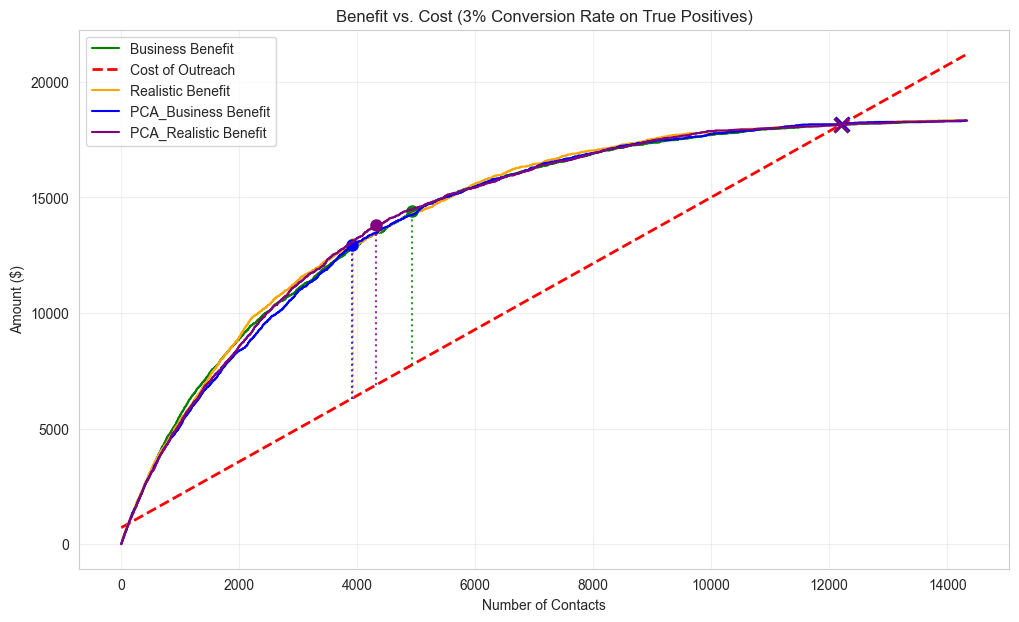

In [43]:
# Constants from the problem description
profit_per_sale = 34 * 10 # $170 Lifetime Value
conversion_rate_right_person = 0.03 # 3% chance of sale if we contact the "Right Person" (True Positive)
calls_per_hour = 21
hourly_wage = 30
cost_per_record = 0.05
    

# Calculate Cost and Benefit per unit
cost_per_contact = hourly_wage / calls_per_hour
# Expected benefit of finding a "Right Person" = Value of Sale * Probability of Sale
expected_benefit_per_right_person = profit_per_sale * conversion_rate_right_person

required_precision = cost_per_contact / expected_benefit_per_right_person

fix_cost_dataset = cost_per_record * X_test.shape[0] 

print(f"--- Cost-Benefit Analysis Parameters ---")
print(f"Hourly Wage: ${hourly_wage:.2f}")
print(f"Cost per Contact: ${cost_per_contact:.2f}")
print(f"Value per Sale: ${profit_per_sale:.2f}")
print(f"Conversion Rate (Given Right Person): {conversion_rate_right_person:.1%}")
print(f"Expected Benefit per 'Right Person' Contacted: ${expected_benefit_per_right_person:.2f}")
print(f"Required Precision to Break Even: {required_precision:.2%}")
print(f"----------------------------------------")

# Plot Benefit vs Cost Curves
plt.figure(figsize=(12, 7))

target_datasets = ['Business', 'Realistic', 'PCA_Business', 'PCA_Realistic']
colors = {'Business': 'green', 'Realistic': 'orange', 'PCA_Business': 'blue', 'PCA_Realistic': 'purple'}

cost_plotted = False

for ds_name in target_datasets:
    if 'best_models' in locals() and ds_name in best_models and ds_name in data_splits:
        entry = best_models[ds_name]
        model = entry['Model_Instance']
        
        X_test_curr = data_splits[ds_name]['X_test']
        y_test_curr = data_splits[ds_name]['y_test']
        
        if hasattr(model, "predict_proba"):
            # Get probabilities
            y_prob = model.predict_proba(X_test_curr)[:, 1]
            y_true = np.array(y_test_curr)
            
            # Sort by probability (Model Ranking)
            sorted_indices = np.argsort(y_prob)[::-1]
            sorted_y_true = y_true[sorted_indices]
            
            # Calculate Cumulative Benefit
            # Benefit accumulates only when we find a "Right Person" (y_true=1)
            # Value = Count of True Positives * Expected Benefit per Right Person
            cum_true_positives = np.cumsum(sorted_y_true)
            benefit = cum_true_positives * expected_benefit_per_right_person
            
            # Calculate Cumulative Cost
            # Cost accumulates for every person contacted
            n = len(y_true)
            cum_contacted = np.arange(1, n + 1)
            cost = cum_contacted * cost_per_contact + fix_cost_dataset
            
            # X-axis: Number of contacts
            x_axis = cum_contacted

            
            # Plot Benefit Curve
            p = plt.plot(x_axis, benefit, label=f"{ds_name} Benefit", color=colors.get(ds_name, 'gray'))
            
            # Plot Cost Curve (only once)
            if not cost_plotted:
                plt.plot(x_axis, cost, label='Cost of Outreach', color='red', linestyle='--', linewidth=2)
                cost_plotted = True
            
            # Find Break-even point (Intersection of Benefit and Cost)
            profit = benefit - cost
            
            # --- Added: Max Profit Point ---
            max_profit_idx = np.argmax(profit)
            max_profit_val = profit[max_profit_idx]
            
            # Plot Max Profit Point
            plt.plot(x_axis[max_profit_idx], benefit[max_profit_idx], 'o', 
                     color=colors.get(ds_name, 'gray'), markersize=8)
            
            # Draw a vertical line to show the max distance
            plt.vlines(x=x_axis[max_profit_idx], ymin=cost[max_profit_idx], ymax=benefit[max_profit_idx], 
                       colors=colors.get(ds_name, 'gray'), linestyles='dotted', alpha=0.8)
            
            # Annotate Max Profit
            plt.annotate(f"", 
                         (x_axis[max_profit_idx], benefit[max_profit_idx]),
                         textcoords="offset points", xytext=(-20, 10), ha='right', color=colors.get(ds_name, 'gray'))
            
            print(f"{ds_name} Max Profit: ${max_profit_val:.2f} at {x_axis[max_profit_idx]} contacts ({x_axis[max_profit_idx]/n:.1%} of population)")
            
            # -------------------------------            
            profitable_mask = profit > 0
            if np.any(profitable_mask):
                last_profitable_idx = np.where(profitable_mask)[0][-1]
                
                # Mark the break-even point
                plt.plot(x_axis[last_profitable_idx], benefit[last_profitable_idx], 'x', 
                         color=colors.get(ds_name, 'gray'), markersize=10, markeredgewidth=2)
                
plt.title(f'Benefit vs. Cost (3% Conversion Rate on True Positives)')
plt.xlabel('Number of Contacts')
plt.ylabel('Amount ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

---

# 5. Fairness

In [54]:
from fairlearn.metrics import MetricFrame, selection_rate, true_positive_rate, false_positive_rate, demographic_parity_difference, demographic_parity_ratio, equalized_odds_difference

# Settings
MIN_N = 50
attrs = ['AGEP', 'age_group', 'SEX', 'MAR', 'mariage_status_simple', 'MIG', 'NATIVITY', 'RAC1P', 'HISP', 'has_any_disability']
mappings = {
    "SEX": {1: "Male", 2: "Female"},
    "RAC1P": {1: "White", 2: "Black", 3: "Amer. Indian", 4: "Alaska Native", 5: "Amer. Indian/Alaska", 6: "Asian", 7: "Native Hawaiian", 8: "Other Pacific Isl.", 9: "Two or More"}
}

# Identify the best model from Section 3 (all_results)

    best_entry = sorted(all_results, key=lambda x: x.get('Val_PR_AUC', 0), reverse=True)[0]
    model = best_entry['Model_Instance']
    ds_name = best_entry['Dataset']
    print(f"Evaluating Fairness for Best Model: {best_entry['Model']} on {ds_name}")
    
    # Get appropriate test set
    if ds_name in data_splits:
        X_eval = data_splits[ds_name]['X_test']
        y_eval = data_splits[ds_name]['y_test']
    else:
        X_eval, y_eval = X_test, y_test

    # Predict
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_eval)[:, 1]
        y_pred = (y_prob >= 0.5).astype(int)
    else:
        y_pred = model.predict(X_eval)
        
    # Helper to prepare sensitive features
    def get_sensitive_feature(attr, df, index):
        s = df.loc[index, attr].copy()
        if attr in mappings:
            s = s.map(mappings[attr]).fillna(s)
        s = s.astype(str)
        # Removed collapsing rare groups to "Other"
        return s

    # Calculate Metrics
    rows = []
    for attr in [a for a in attrs if a in df_2_3.columns]:
        s = get_sensitive_feature(attr, df_2_3, X_eval.index)
        
        # Fairlearn Metrics
        dpd = demographic_parity_difference(y_eval, y_pred, sensitive_features=s)
        dpr = demographic_parity_ratio(y_eval, y_pred, sensitive_features=s)
        eod = equalized_odds_difference(y_eval, y_pred, sensitive_features=s)
        
        # Manual TPR Gap calculation using MetricFrame
        mf = MetricFrame(
            metrics={"TPR": true_positive_rate},
            y_true=y_eval,
            y_pred=y_pred,
            sensitive_features=s
        )
        tpr_gap = mf.by_group["TPR"].max() - mf.by_group["TPR"].min()
        
        # Four-Fifths Rule Check (DI >= 0.8)
        # Fairlearn's DPR is always <= 1 (min/max). 
        # If DPR < 0.8, it violates the 4/5ths rule.
        is_fair_4_5 = dpr >= 0.8
        
        rows.append({
            "Attribute": attr,
            "DPD": dpd,
            "EOD": eod,
            "TPR_Gap": tpr_gap,
            "DPR (DI)": dpr,
            "Fair (4/5ths Rule)": "Yes" if is_fair_4_5 else "No"
        })

    fairness_df = pd.DataFrame(rows)
    
    # Display
    print("\nFairness Assessment (Four-Fifths Rule: DI >= 0.8)")
    display(fairness_df.round(4))


IndentationError: unexpected indent (1689206222.py, line 13)

Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


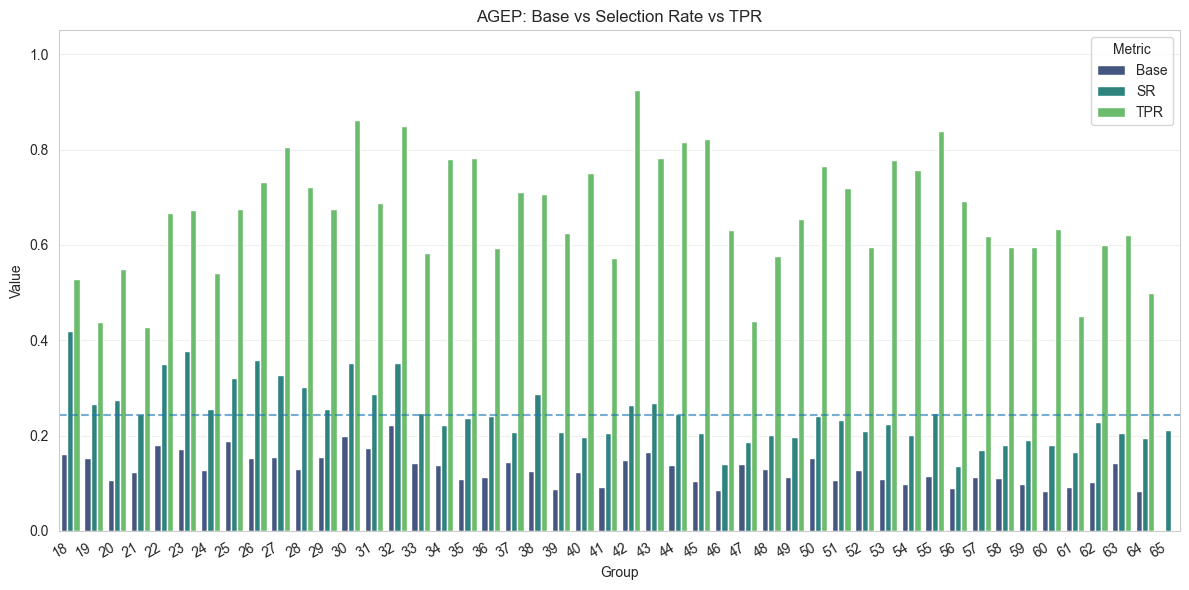

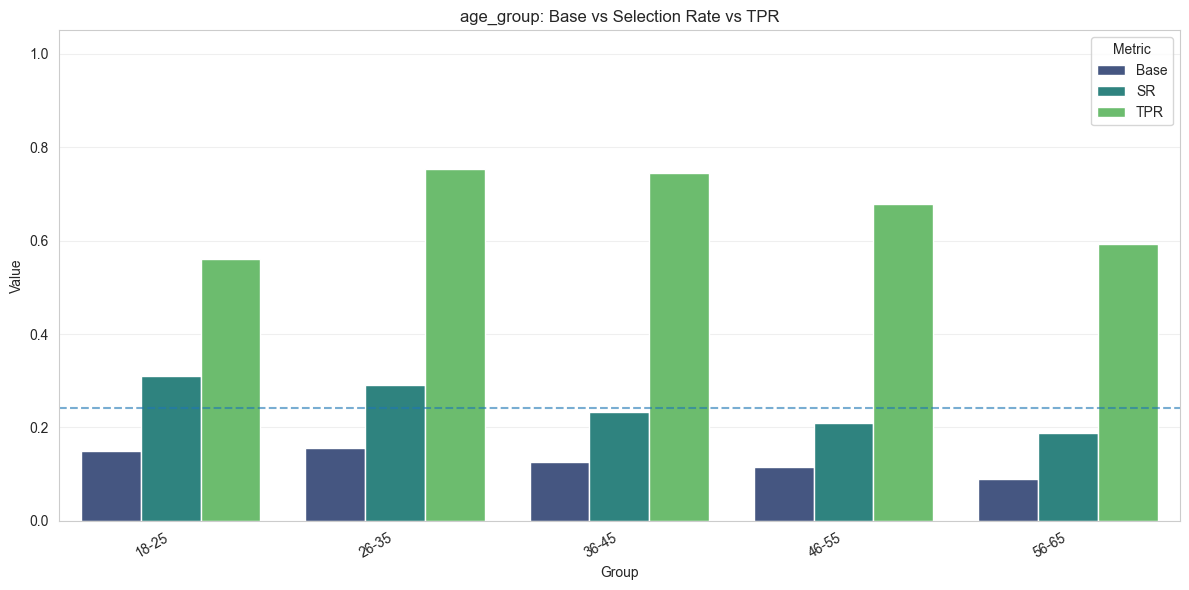

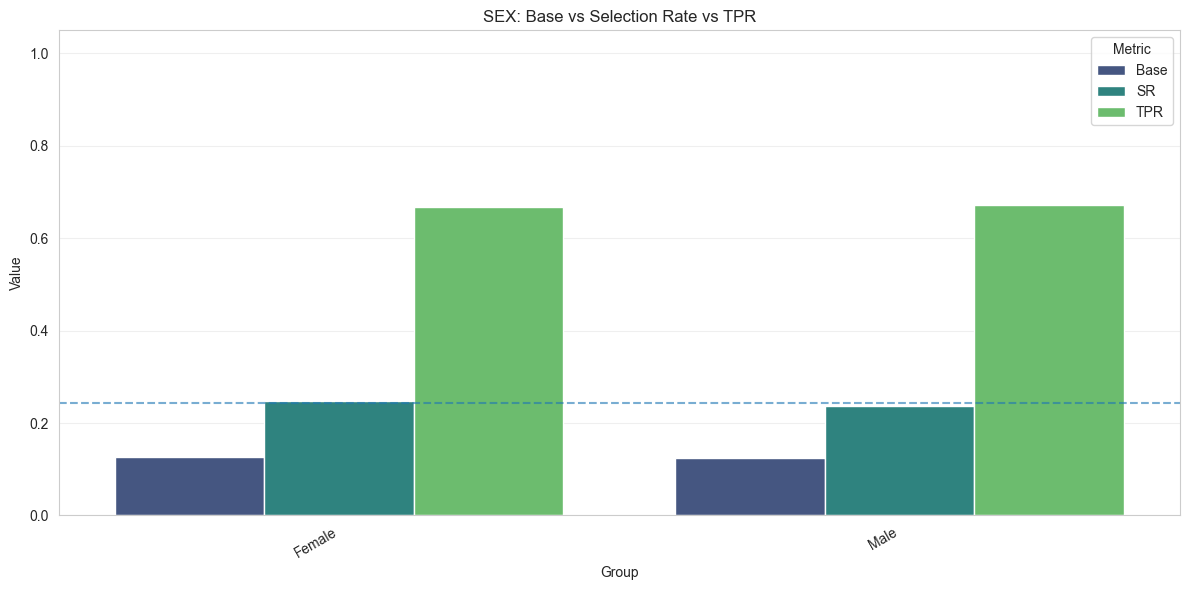

Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


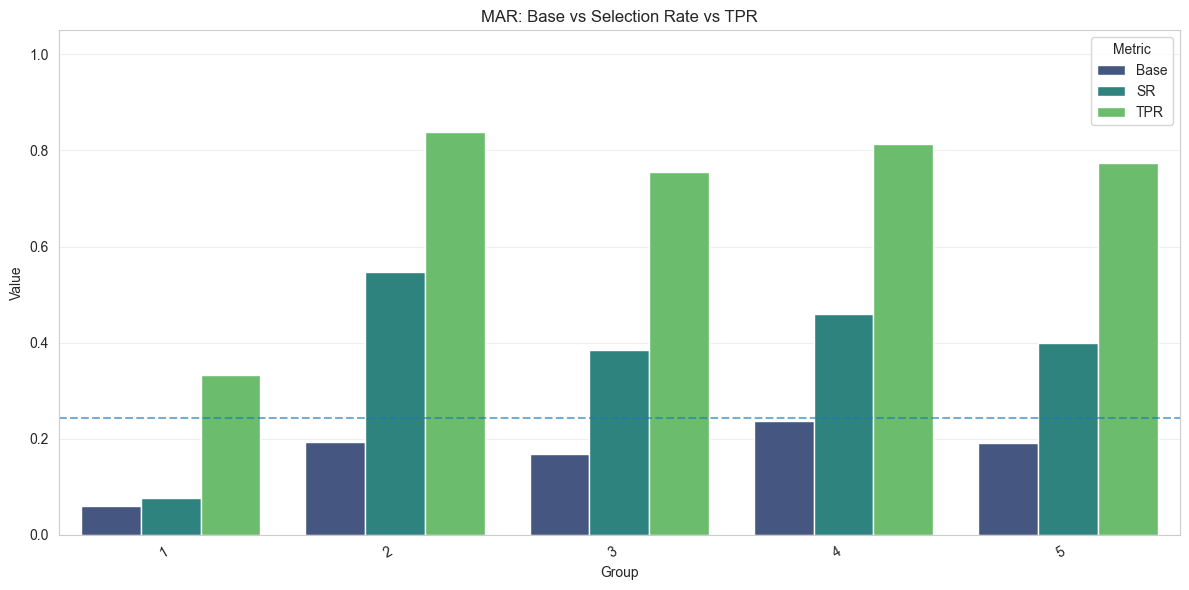

Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


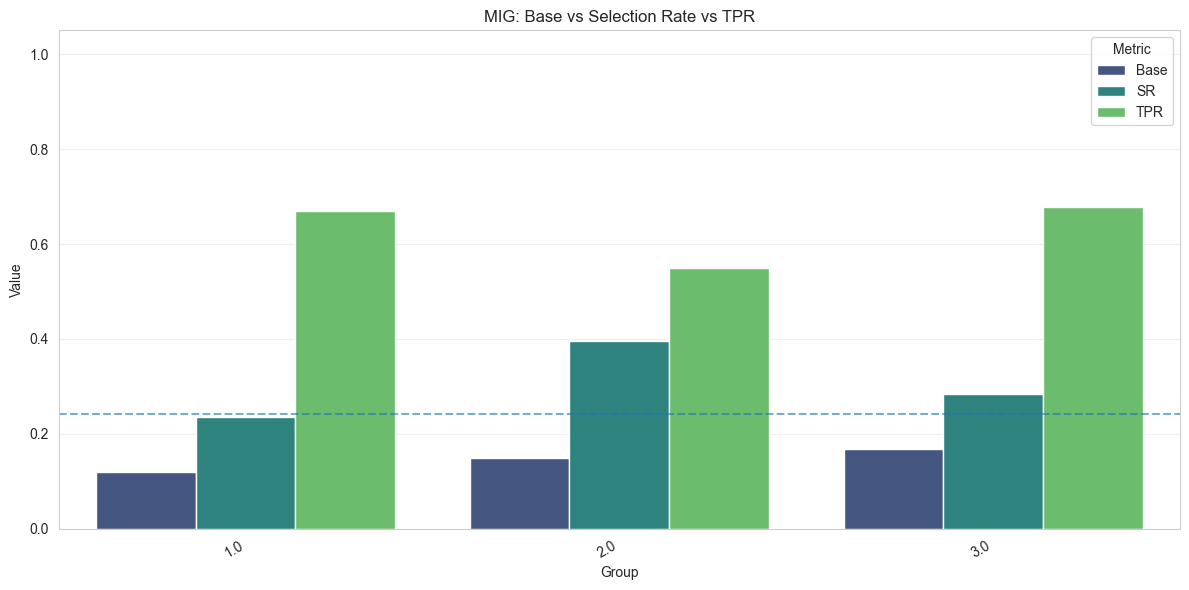

Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


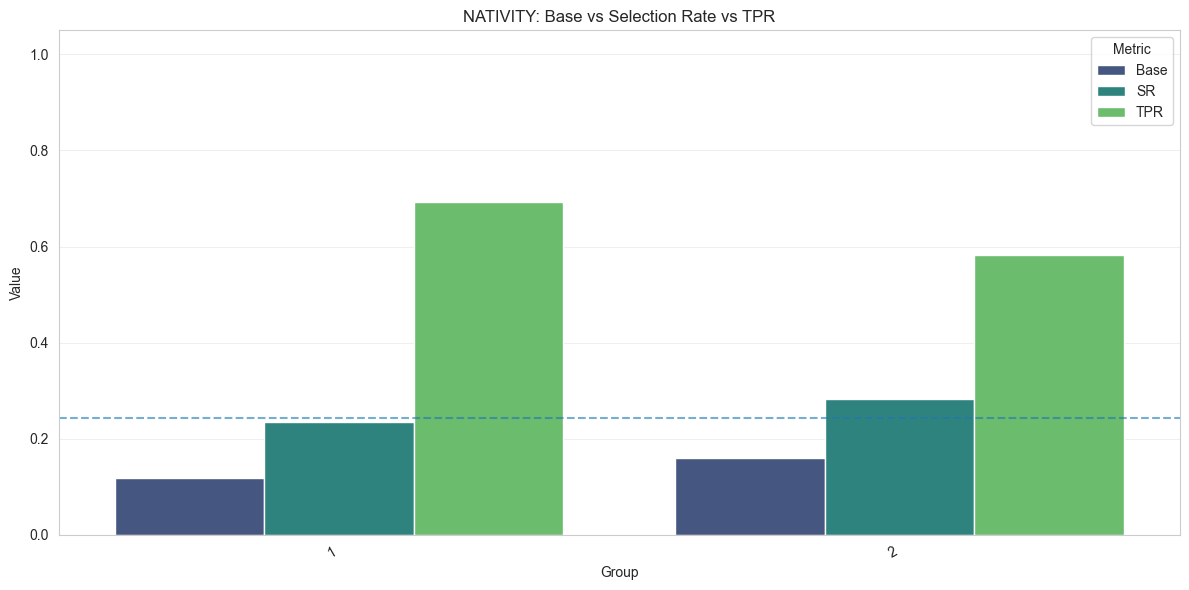

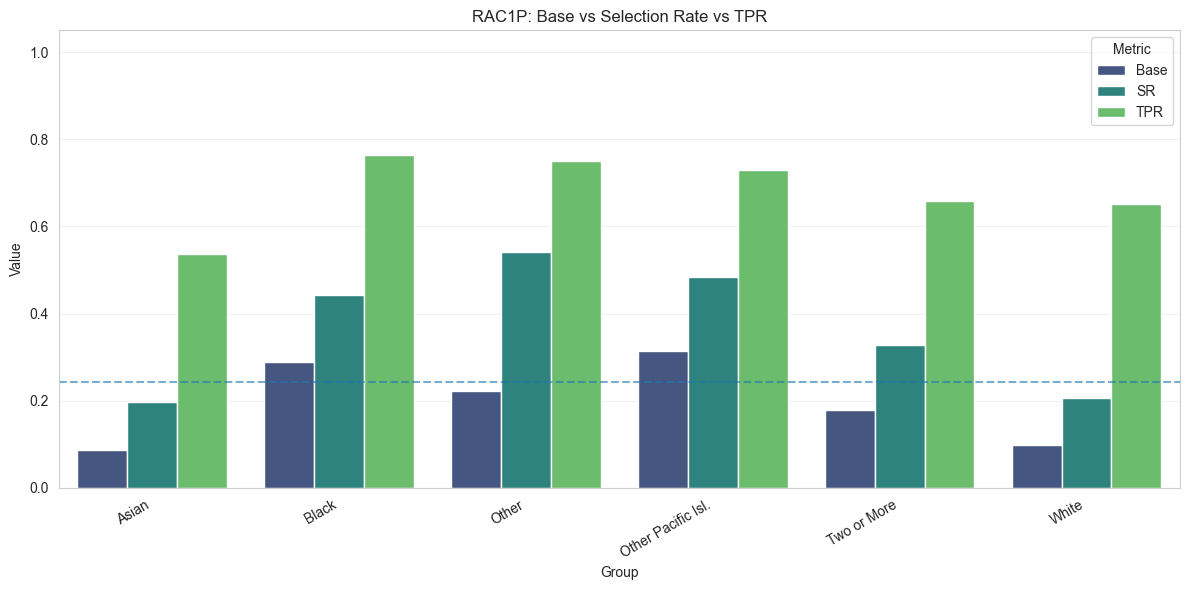

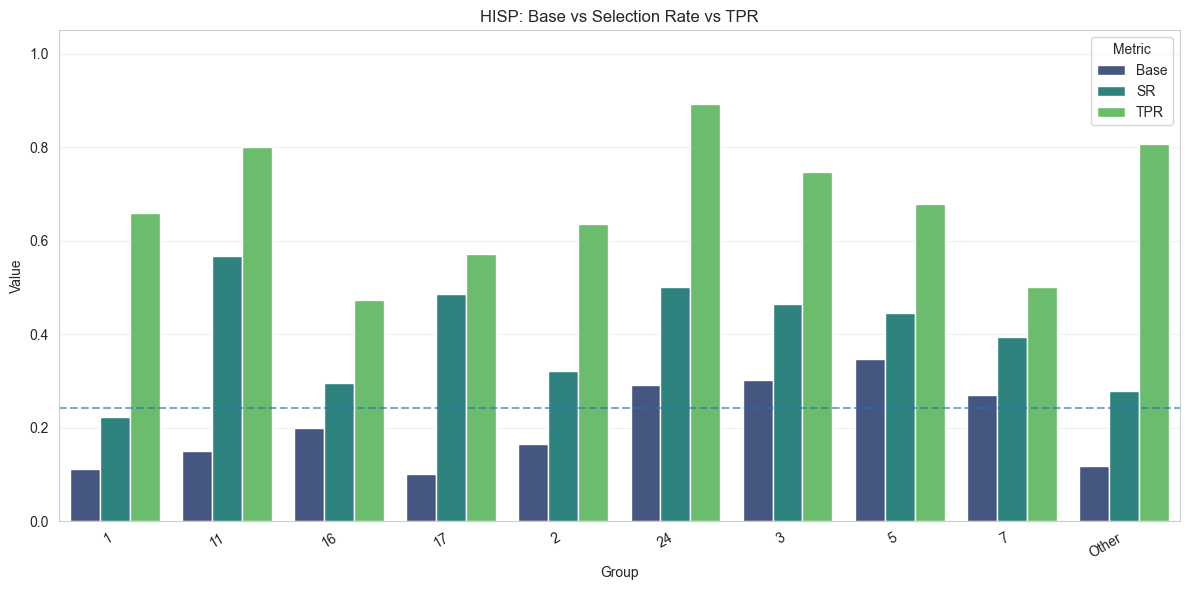

Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


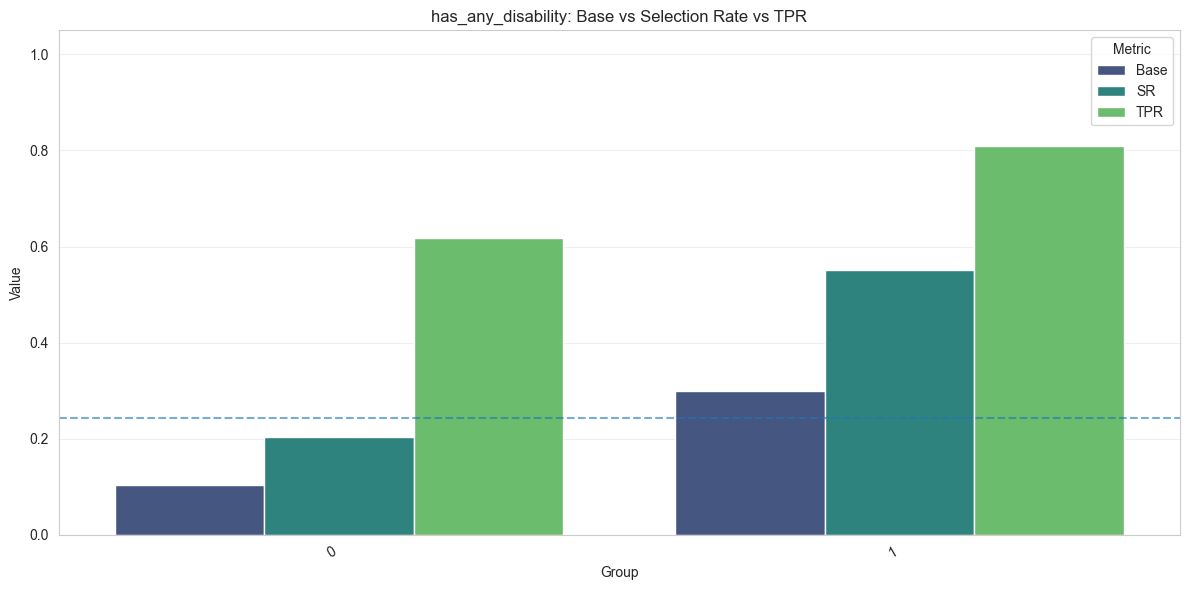

In [53]:
overall_sr=float(np.mean(y_pred))

for a in [x for x in attrs if x in df_2_3.columns]:
    s=sens(a)
    g=MetricFrame(metrics={"Base":lambda yt,yp:float(np.mean(yt)),"SR":selection_rate,"TPR":true_positive_rate},
                  y_true=y_eval, y_pred=y_pred, sensitive_features=s).by_group.reset_index()
    g.columns=["Group","Base","SR","TPR"]
    plot_df=g.melt("Group", var_name="Metric", value_name="Value")

    plt.figure(figsize=(12,6))
    sns.barplot(data=plot_df, x="Group", y="Value", hue="Metric", palette="viridis")
    plt.axhline(overall_sr, linestyle="--", alpha=0.6, label="Overall SR")
    plt.title(f"{a}: Base vs Selection Rate vs TPR"); plt.ylim(0,1.05)
    plt.xticks(rotation=30, ha="right"); plt.grid(axis="y", alpha=0.3)
    plt.tight_layout(); plt.show()

---

## 6. Re-Training without RAC1P

In [46]:
# Define new feature sets without RAC1P and other sensitive attributes
cols_realistic_v2 = [
    'income_group', 'has_wage_income', 'has_self_employment',
    'employment_status_simple', 'employer_type',
    'SEX',
    'education_level', 'currently_enrolled',
    'STATE', 'PUMA'
]

cols_business_v2 = [
    'WAGP', 'SEMP', 'income_source_count', 'has_wage_income', 'has_self_employment',
    'WKL', 'OCCP_2digit', 'INDP_2digit', 'employment_status_simple', 'employer_type', 'SEX',
    'education_level', 'currently_enrolled', 'has_any_disability',
    'STATE', 'PUMA'
]

print("=== Re-Training Models Without RAC1P ===\n")

# Create new feature sets
feature_sets_v2 = {}

if 'df_2_3' in locals():
    # Business V2
    X_bus_v2, y_bus_v2 = preprocess_set(df_2_3, cols_business_v2, "Business_V2")
    feature_sets_v2['Business_V2'] = (X_bus_v2, y_bus_v2)
    
    # Realistic V2
    X_real_v2, y_real_v2 = preprocess_set(df_2_3, cols_realistic_v2, "Realistic_V2")
    feature_sets_v2['Realistic_V2'] = (X_real_v2, y_real_v2)
    
    # Display shapes
    print("Feature Sets Created:")
    for name, (X, y) in feature_sets_v2.items():
        print(f"  {name:<20}: {X.shape[1]} features, {X.shape[0]} rows")
else:
    print("Error: df_2_3 not found. Please run previous cells.")

# Split datasets
data_splits_v2 = {}

print("\n--- Splitting Data ---")
for set_name, (X, y) in feature_sets_v2.items():
    X_train, X_val, X_test, y_train, y_val, y_test = split_dataset(X, y)
    
    data_splits_v2[set_name] = {
        'X_train': X_train, 'y_train': y_train,
        'X_val': X_val, 'y_val': y_val,
        'X_test': X_test, 'y_test': y_test
    }
    
    print(f"  {set_name}: Train={X_train.shape[0]}, Val={X_val.shape[0]}, Test={X_test.shape[0]}")

# Apply SMOTE
print("\n--- Applying SMOTE to Training Sets ---")
for set_name, splits in data_splits_v2.items():
    X_train_orig = splits['X_train']
    y_train_orig = splits['y_train']
    
    smote = SMOTE(random_state=42)
    X_train_res, y_train_res = smote.fit_resample(X_train_orig, y_train_orig)
    
    data_splits_v2[set_name]['X_train'] = X_train_res
    data_splits_v2[set_name]['y_train'] = y_train_res
    
    orig_dist = y_train_orig.value_counts(normalize=True).mul(100).round(2).to_dict()
    res_dist = y_train_res.value_counts(normalize=True).mul(100).round(2).to_dict()
    
    print(f"\n  {set_name}:")
    print(f"    Original: {orig_dist}")
    print(f"    After SMOTE: {res_dist}")
    print(f"    New Train Shape: {X_train_res.shape}")


=== Re-Training Models Without RAC1P ===

Feature Sets Created:
  Business_V2         : 211 features, 95533 rows
  Realistic_V2        : 19 features, 95533 rows

--- Splitting Data ---
  Business_V2: Train=66873, Val=14330, Test=14330
  Realistic_V2: Train=66873, Val=14330, Test=14330

--- Applying SMOTE to Training Sets ---

  Business_V2:
    Original: {0: 87.47, 1: 12.53}
    After SMOTE: {0: 50.0, 1: 50.0}
    New Train Shape: (116982, 211)

  Realistic_V2:
    Original: {0: 87.47, 1: 12.53}
    After SMOTE: {0: 50.0, 1: 50.0}
    New Train Shape: (116982, 19)


In [47]:
# --- Define Models and Parameters ---
models_to_train = [
    {
        "name": "LogisticRegression",
        "model": LogisticRegression(random_state=42),
        "params": {
            'C': [0.01, 0.1, 1, 10],
            'penalty': ['l2'],
            'solver': ['lbfgs'],
            'max_iter': [1000]
        }
    },
    {
        "name": "RandomForest",
        "model": RandomForestClassifier(random_state=42),
        "params": {
            'n_estimators': [200],
            'max_depth': [3,5],
            'min_samples_split': [10, 20, 50]
        }
    },
    {
        "name": "XGBoost",
        "model": XGBClassifier(use_label_encoder=False, random_state=42, eval_metric='aucpr'),
        "params": {
            "learning_rate": [0.05],  
            "n_estimators": [200],         
            "max_depth": [3],

            "min_child_weight": [5, 10],
            'gamma': [2,4],  
            "reg_alpha": [0.1, 0.5], 
            "reg_lambda": [2.0],


            "subsample": [0.8],                 
            "colsample_bytree": [0.8],      
            "tree_method": ["auto"],            
            "device": ["cuda"],                 
            "eval_metric": ["aucpr"],
        }
    },
    {
        "name": "NeuralNetwork",
        "model": MLPClassifier(random_state=42),
        "params": {
            'hidden_layer_sizes': [(32,), (64, 32)],
            'activation': ['relu'],
            'alpha': [0.05],
            'learning_rate': ['adaptive'],
            'learning_rate_init': [0.001],
            'batch_size': [64],
            'max_iter': [300]
            }
    }
]

results_v2 = []

print("\n=== Training Models (LR, RF, XGB, NN) ===\n")

if 'data_splits_v2' in locals():
    for model_info in models_to_train:
        for set_name, splits in data_splits_v2.items():
            res = train_and_tune(
                model_info['model'],
                model_info['params'],
                splits['X_train'], splits['y_train'],
                splits['X_val'], splits['y_val'],
                model_info['name'], set_name
            )
            results_v2.append(res)


=== Training Models (LR, RF, XGB, NN) ===

Training LogisticRegression on Business_V2...
  -> Best Params: {'C': 0.1, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'lbfgs'}
  -> Val PR-AUC: 0.3736
  -> Train PR-AUC: 0.7922
  -> Training Time: 34.55 seconds
Training LogisticRegression on Realistic_V2...
  -> Best Params: {'C': 0.01, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'lbfgs'}
  -> Val PR-AUC: 0.3523
  -> Train PR-AUC: 0.7813
  -> Training Time: 2.87 seconds
Training RandomForest on Business_V2...
  -> Best Params: {'max_depth': 5, 'min_samples_split': 20, 'n_estimators': 200}
  -> Val PR-AUC: 0.3417
  -> Train PR-AUC: 0.8327
  -> Training Time: 81.41 seconds
Training RandomForest on Realistic_V2...
  -> Best Params: {'max_depth': 5, 'min_samples_split': 50, 'n_estimators': 200}
  -> Val PR-AUC: 0.3394
  -> Train PR-AUC: 0.7793
  -> Training Time: 36.71 seconds
Training XGBoost on Business_V2...
  -> Best Params: {'colsample_bytree': 0.8, 'device': 'cuda', 'eval_metric': 'aucpr


=== Validation Performance (PR-AUC) ===



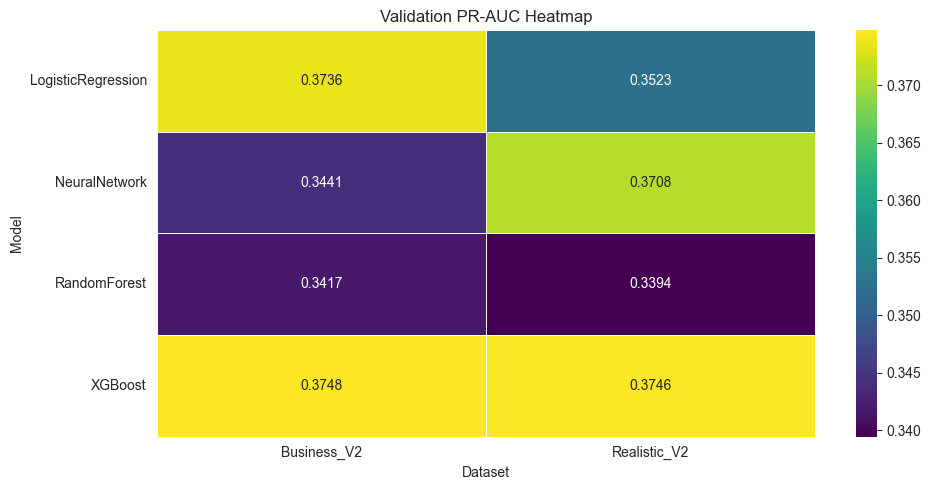


=== Test Performance (PR-AUC) ===



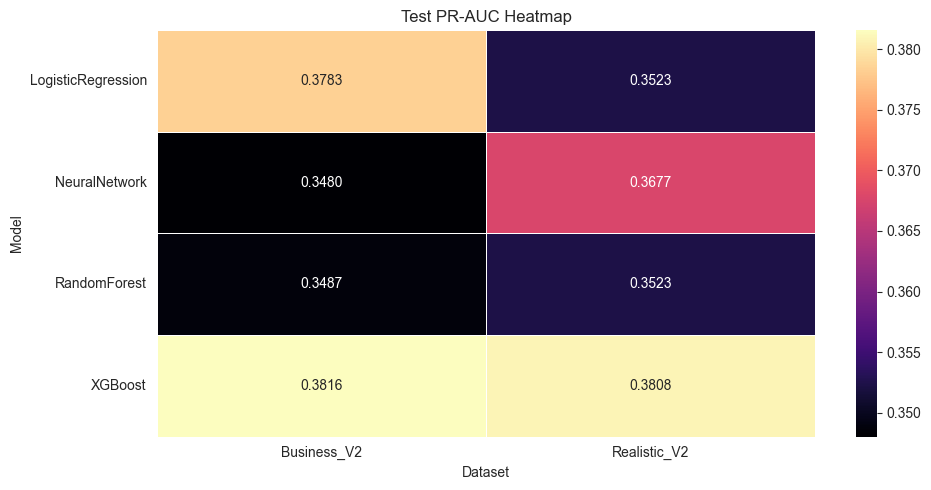


=== Cost-Benefit Analysis (Best Models) ===

Cost per Contact: $1.43
Expected Benefit per Right Person: $10.20
Required Precision to Break Even: 14.01%

--- Business_V2 (Best Model: XGBoost) ---
  Max Profit: $6,329.41
  At 5,428 contacts (37.9% of population)
  Break-even at: 12,257 contacts (85.5%)

--- Realistic_V2 (Best Model: XGBoost) ---
  Max Profit: $6,156.13
  At 5,228 contacts (36.5% of population)
  Break-even at: 12,250 contacts (85.5%)



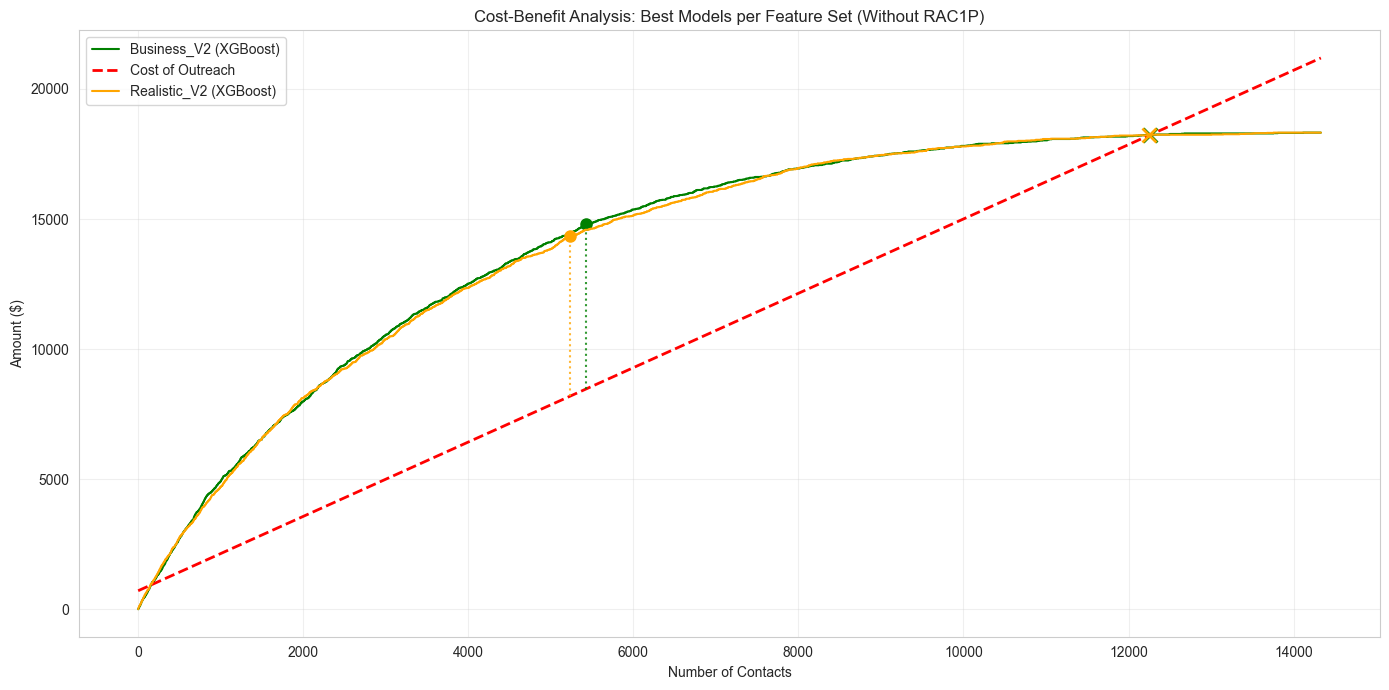

In [48]:
# --- 1. Heatmap: Validation PR-AUC ---
print("\n=== Validation Performance (PR-AUC) ===\n")
results_df_v2 = pd.DataFrame(results_v2)

if not results_df_v2.empty:
    pivot_val = results_df_v2.pivot_table(index='Model', columns='Dataset', values='Val_PR_AUC', aggfunc='mean')
    
    plt.figure(figsize=(10, 5))
    sns.heatmap(pivot_val, annot=True, fmt=".4f", cmap='viridis', linewidths=.5)
    plt.title('Validation PR-AUC Heatmap')
    plt.tight_layout()
    plt.show()
else:
    print("No results to display.")

# --- 2. Heatmap: Test PR-AUC ---
print("\n=== Test Performance (PR-AUC) ===\n")
test_results_v2 = []

for res in results_v2:
    dataset_name = res['Dataset']
    model_instance = res['Model_Instance']
    
    if dataset_name in data_splits_v2:
        X_test_curr = data_splits_v2[dataset_name]['X_test']
        y_test_curr = data_splits_v2[dataset_name]['y_test']
        
        if hasattr(model_instance, "predict_proba"):
            y_prob = model_instance.predict_proba(X_test_curr)[:, 1]
        else:
            y_prob = model_instance.predict(X_test_curr)
            
        test_pr_auc = average_precision_score(y_test_curr, y_prob)
        
        test_results_v2.append({
            'Dataset': dataset_name,
            'Model': res['Model'],
            'Test_PR_AUC': test_pr_auc,
            'Model_Instance': model_instance
        })

test_results_df_v2 = pd.DataFrame(test_results_v2)

if not test_results_df_v2.empty:
    pivot_test = test_results_df_v2.pivot_table(index='Model', columns='Dataset', values='Test_PR_AUC', aggfunc='mean')
    
    plt.figure(figsize=(10, 5))
    sns.heatmap(pivot_test, annot=True, fmt=".4f", cmap='magma', linewidths=.5)
    plt.title('Test PR-AUC Heatmap')
    plt.tight_layout()
    plt.show()
else:
    print("No test results to display.")

# --- 3. Cost-Benefit Analysis (Best Model per Dataset) ---
print("\n=== Cost-Benefit Analysis (Best Models) ===\n")

# Constants
profit_per_sale = 34 * 10  # $340 Lifetime Value
conversion_rate_right_person = 0.03  # 3% conversion rate
calls_per_hour = 21
hourly_wage = 30
cost_per_record = 0.05

cost_per_contact = hourly_wage / calls_per_hour
expected_benefit_per_right_person = profit_per_sale * conversion_rate_right_person

print(f"Cost per Contact: ${cost_per_contact:.2f}")
print(f"Expected Benefit per Right Person: ${expected_benefit_per_right_person:.2f}")
print(f"Required Precision to Break Even: {cost_per_contact / expected_benefit_per_right_person:.2%}\n")

# Identify best model for each dataset based on Test PR-AUC
best_models_v2 = {}
for ds in ['Business_V2', 'Realistic_V2']:
    ds_results = [r for r in test_results_v2 if r['Dataset'] == ds]
    if ds_results:
        best_entry = max(ds_results, key=lambda x: x['Test_PR_AUC'])
        best_models_v2[ds] = best_entry

plt.figure(figsize=(14, 7))
colors = {'Business_V2': 'green', 'Realistic_V2': 'orange'}
cost_plotted = False

for ds_name, entry in best_models_v2.items():
    model = entry['Model_Instance']
    model_name = entry['Model']
    
    print(f"--- {ds_name} (Best Model: {model_name}) ---")
    
    X_test_curr = data_splits_v2[ds_name]['X_test']
    y_test_curr = data_splits_v2[ds_name]['y_test']
    
    # Get predictions
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test_curr)[:, 1]
    else:
        y_prob = model.predict(X_test_curr)
        
    y_true = np.array(y_test_curr)
    
    # Sort by probability
    sorted_indices = np.argsort(y_prob)[::-1]
    sorted_y_true = y_true[sorted_indices]
    
    # Calculate cumulative benefit
    cum_true_positives = np.cumsum(sorted_y_true)
    benefit = cum_true_positives * expected_benefit_per_right_person
    
    # Calculate cumulative cost
    n = len(y_true)
    cum_contacted = np.arange(1, n + 1)
    fix_cost = cost_per_record * n
    cost = cum_contacted * cost_per_contact + fix_cost
    
    # Plot benefit curve
    plt.plot(cum_contacted, benefit, label=f"{ds_name} ({model_name})", color=colors.get(ds_name, 'gray'))
    
    # Plot cost curve (only once)
    if not cost_plotted:
        plt.plot(cum_contacted, cost, label='Cost of Outreach', color='red', linestyle='--', linewidth=2)
        cost_plotted = True
    
    # Calculate profit
    profit = benefit - cost
    max_profit_idx = np.argmax(profit)
    max_profit_val = profit[max_profit_idx]
    
    # Mark max profit point
    plt.plot(cum_contacted[max_profit_idx], benefit[max_profit_idx], 'o', 
             color=colors.get(ds_name, 'gray'), markersize=8)
    plt.vlines(x=cum_contacted[max_profit_idx], ymin=cost[max_profit_idx], 
               ymax=benefit[max_profit_idx], colors=colors.get(ds_name, 'gray'), 
               linestyles='dotted', alpha=0.8)
    
    print(f"  Max Profit: ${max_profit_val:,.2f}")
    print(f"  At {cum_contacted[max_profit_idx]:,} contacts ({cum_contacted[max_profit_idx]/n:.1%} of population)")
    
    # Break-even point
    profitable_mask = profit > 0
    if np.any(profitable_mask):
        last_profitable_idx = np.where(profitable_mask)[0][-1]
        plt.plot(cum_contacted[last_profitable_idx], benefit[last_profitable_idx], 'x', 
                 color=colors.get(ds_name, 'gray'), markersize=10, markeredgewidth=2)
        print(f"  Break-even at: {cum_contacted[last_profitable_idx]:,} contacts ({cum_contacted[last_profitable_idx]/n:.1%})")
    else:
        print(f"  No profitable range found")
    print()

plt.title('Cost-Benefit Analysis: Best Models per Feature Set (Without RAC1P)')
plt.xlabel('Number of Contacts')
plt.ylabel('Amount ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()